# Coding Pipeline for Bachelor's Thesis Project - Machine and Deep Learning Approaches to Heart Rate Estimation from Speech with Interpretability and Fairness Analysis

# Problems/questions:

- poor performance of the xgboost (too many different parameters for the same bpm)
- is there no data leakage if I minmax normalise but per speaker and then split speaker-independently?
- maybe I go back to training with recording features?
- how important is a stratified grid search?
- is my training approach appropriate?

In [1]:
# Display settings 

import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.set_printoptions(suppress=True, precision=4)

## Data loading and exploration

Start by verifying that the extracted feature dataset is internally consistent and ready for speaker-independent modeling. Since your project emphasizes speaker separation, fairness, and subgroup evaluation, this stage should check whether the rows, labels, and metadata all line up before any modeling begins.

Suggested exploration steps:

	•	Inspect table shape, feature types, missing values, duplicates, and target distribution.
	•	Check how many recordings each speaker contributes, and whether HR values are repeated across tasks or conditions.
	•	Plot the target distribution of heart rate, plus distributions by sex, language, age group, and task type.
	•	Examine correlations among features, especially among MFCCs, and look for constant or near-constant columns.
	•	Check whether any speakers or groups are underrepresented, because that will affect fairness analysis later.

Useful starter outputs:

	•	Summary statistics for all numeric features.
	•	Missingness heatmap.
	•	Histograms of HR and selected feature families.
	•	Boxplots of HR by demographic group.
	•	Scatter or pair plots for a small subset of important features.

In [20]:
import pandas as pd

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
#metadata_df = pd.read_csv("tesdhe_metadata.csv")

df.head()

,file_name,frame_idx,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm
0,En001M240401A083.ogg,0,0.7849,0.2669,0.4113,0.4503,0.4612,0.4746,0.5941,0.5748,0.5732,0.5814,0.4272,0.6706,0.4873,0.5379,0.7363,0.6437,0.5866,0.5846,0.4808,0.5650,0.0000,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
1,En001M240401A083.ogg,1,0.7908,0.1812,0.6004,0.4147,0.4591,0.5637,0.5078,0.5914,0.5314,0.5528,0.3849,0.6528,0.5172,0.5171,0.6419,0.4883,0.6400,0.5952,0.4046,0.5316,0.0000,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
2,En001M240401A083.ogg,2,0.7807,0.1332,0.5887,0.5038,0.4605,0.5496,0.6952,0.5672,0.4645,0.5144,0.2986,0.5709,0.5506,0.5690,0.6522,0.5057,0.6197,0.5280,0.4263,0.6465,0.5646,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
3,En001M240401A083.ogg,3,0.8105,0.1693,0.6339,0.4811,0.4660,0.4986,0.6460,0.5748,0.5643,0.6203,0.3689,0.5561,0.4612,0.6280,0.5815,0.4949,0.7322,0.5926,0.3445,0.6811,0.5602,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
4

The dataset was also checked for any missing values
in the extracted MFCC coeﬃcients and was then normalized using MinMax normalizer to scale the MFCC
coeﬃcients in the range of [0,1] interval. Rows which
had missing MFCC coeﬃcients were discarded and not
used in the analysis. Of the 42 × 20= 840 rows of
MFCCcoeﬃcients,60rowswerediscardedduetomiss-
ing MFCC coeﬃcients. This results in a total of 780
rows of MFCC coeﬃcients with their corresponding
HR values. A histogram of HR values corresponding
to each of these MFCC coeﬃcients is shown in Fig. 1.
Normalization is achieved by shifting the values of each
MFCC coeﬃcient (denoted as x) so that the minimal
value is 0, and dividing by the new maximal coeﬃcient
value, as follows:
Normalized value=
x−min(x)
[max(x)−min(x)].

Shape: (10034, 13)

Columns:
['file_name', 'language_code', 'language', 'speaker_id', 'gender', 'age_raw', 'age_years', 'age_months', 'question_number', 'response_type_code', 'response_type', 'bpm', 'extension']

Dtypes:
file_name               str
language_code           str
language                str
speaker_id            int64
gender                  str
age_raw               int64
age_years             int64
age_months            int64
question_number       int64
response_type_code      str
response_type           str
bpm                   int64
extension               str
dtype: object

First rows:
              file_name language_code language  speaker_id gender  age_raw  \
0  En001M240401A083.ogg            En  English           1      M     2404   
1  En001M240402A079.ogg            En  English           1      M     2404   
2  En001M240403A076.ogg            En  English           1      M     2404   
3  En001M240404A076.ogg            En  English           1      M     2404  

KeyboardInterrupt: 

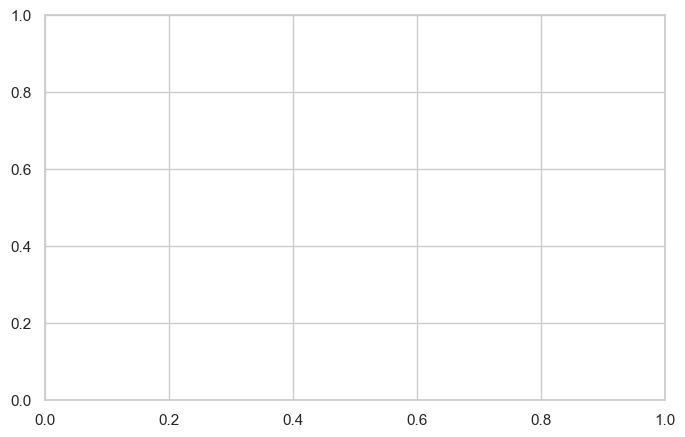

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Config ----------
DATA_PATH = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv"

TARGET_COL = "bpm"
SPEAKER_COL = "speaker_id"
SEX_COL = "gender"
LANG_COL = "language"
AGE_COL = "age_years"

OUTPUT_DIR = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/exploration"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- Load ----------
df = pd.read_csv(DATA_PATH)

# ---------- Basic overview ----------
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nFirst rows:")
print(df.head())

print("\nBasic numeric summary:")
print(df.describe(include=[np.number]).T)

print("\nCategorical summary:")
for col in [SEX_COL, LANG_COL]:
    if col in df.columns:
        print(f"\nValue counts: {col}")
        print(df[col].value_counts(dropna=False))

# ---------- Speaker-level overview ----------
print("\nUnique speakers:", df[SPEAKER_COL].nunique())

samples_per_speaker = df.groupby(SPEAKER_COL).size().sort_values(ascending=False)
print("\nSamples per speaker:")
print(samples_per_speaker.describe())

samples_per_speaker.to_csv(f"{OUTPUT_DIR}/samples_per_speaker.csv")

# ---------- Missing values ----------
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nMissing values:")
print(missing)

missing.to_csv(f"{OUTPUT_DIR}/missing_values.csv", header=["n_missing"])

# ---------- Save full summary ----------
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "n_unique": df.nunique(dropna=False)
})
summary.to_csv(f"{OUTPUT_DIR}/dataset_summary.csv")

# ---------- Plots ----------
sns.set(style="whitegrid")

# Target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET_COL], kde=True, bins=30)
plt.title("Heart Rate Distribution")
plt.xlabel("Heart Rate (BPM)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_rate_distribution.png", dpi=300)
plt.close()

# Samples per speaker
plt.figure(figsize=(10, 5))
sns.histplot(samples_per_speaker, bins=30)
plt.title("Distribution of Samples per Speaker")
plt.xlabel("Number of samples")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/samples_per_speaker_distribution.png", dpi=300)
plt.close()

# Heart rate by sex
if SEX_COL in df.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x=SEX_COL, y=TARGET_COL)
    plt.title("Heart Rate by Sex")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/heart_rate_by_sex.png", dpi=300)
    plt.close()

# Heart rate by language
if LANG_COL in df.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x=LANG_COL, y=TARGET_COL)
    plt.title("Heart Rate by Language")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/heart_rate_by_language.png", dpi=300)
    plt.close()

# Age histogram
if AGE_COL in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[AGE_COL], bins=20, kde=True)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/age_distribution.png", dpi=300)
    plt.close()

# Correlation heatmap for a subset of numeric features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
subset_cols = [TARGET_COL] + [c for c in numeric_cols if c != TARGET_COL][:25]

corr = df[subset_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Subset of Numeric Features)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap_subset.png", dpi=300)
plt.close()


## Train-test design: Speaker-independent splitting
"Since the dataset has more MFCC frames than individuals samples, in this study, we have subjected the
data to (nT = 80%/nt = 20%) split to ensure more
samples are available for training and learning." (Usmat et al 2021)
But they only have 42 individual speakers - I can afford using some more for additional validation to avoid overfitting to the dataset

Your next coding pipeline should define the evaluation protocol before model building. Because your proposal uses speaker-independent cross-validation and subgroup metrics, the split strategy is a core part of the experiment rather than a later detail.

Recommended split logic:

	•	Hold out speakers, not rows.
	•	Use nested speaker-independent cross-validation if feasible.
	•	Keep the final test set untouched until the end.
	•	Stratify as much as possible by sex and language at the speaker level if the sample sizes allow it.

A practical design is:

	•	Outer loop: speaker-wise 10-fold CV for evaluation.
	•	Inner loop: speaker-wise validation split or grid search.
	•	Final holdout: one independent speaker set for the last comparison, if your sample size supports it.

NameError: name 'X_train' is not defined

In [ ]:
# =============================================================================
# Speaker-independent 70/15/15 train/validation/test split with stratification
# across language and gender. Saves speaker_id, file_name, and stratum
# alongside X/y so they can be used for grouped + stratified CV later.
# =============================================================================
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
TRAIN_SIZE   = 0.70
VAL_SIZE     = 0.15
TEST_SIZE    = 0.15

FEATURES_PATH = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
METADATA_PATH = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")
OUTPUT_DIR    = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")

# --- Load data ---------------------------------------------------------------
features = pd.read_parquet(FEATURES_PATH)
metadata = pd.read_csv(METADATA_PATH)

# --- Build a speaker-level table for stratification --------------------------
speakers = (
    metadata.groupby("speaker_id")
            .agg(language=("language", "first"),
                 gender=("gender", "first"))
            .reset_index()
)

# Composite label for stratified sampling (2 x 2 = 4 possible groups).
speakers["stratum"] = speakers["language"] + "_" + speakers["gender"]

# --- Speaker-independent stratified split (two stages) -----------------------
train_speakers, temp_speakers = train_test_split(
    speakers,
    test_size=(VAL_SIZE + TEST_SIZE),     # 0.30
    stratify=speakers["stratum"],
    random_state=RANDOM_STATE,
)

val_speakers, test_speakers = train_test_split(
    temp_speakers,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),   # 0.5
    stratify=temp_speakers["stratum"],
    random_state=RANDOM_STATE,
)

# --- Map speakers back to frame-level rows -----------------------------------
# Attach speaker_id AND the demographic attributes used for stratified CV.
features = features.merge(
    metadata[["file_name", "speaker_id"]], on="file_name", how="left"
).merge(
    speakers[["speaker_id", "language", "gender", "stratum"]],
    on="speaker_id", how="left",
)

train_mask = features["speaker_id"].isin(train_speakers["speaker_id"])
val_mask   = features["speaker_id"].isin(val_speakers["speaker_id"])
test_mask  = features["speaker_id"].isin(test_speakers["speaker_id"])

# --- Build X / y / groups sets -----------------------------------------------
# Drop identifiers and labels from X; keep them in the groups frame.
DROP_COLS  = ["file_name", "frame_idx", "bpm",
              "speaker_id", "language", "gender", "stratum"]
GROUP_COLS = ["speaker_id", "file_name", "language", "gender", "stratum"]

train_rows = features.loc[train_mask].reset_index(drop=True)
val_rows   = features.loc[val_mask].reset_index(drop=True)
test_rows  = features.loc[test_mask].reset_index(drop=True)

X_train, y_train, groups_train = (
    train_rows.drop(columns=DROP_COLS),
    train_rows["bpm"],
    train_rows[GROUP_COLS],
)
X_val, y_val, groups_val = (
    val_rows.drop(columns=DROP_COLS),
    val_rows["bpm"],
    val_rows[GROUP_COLS],
)
X_test, y_test, groups_test = (
    test_rows.drop(columns=DROP_COLS),
    test_rows["bpm"],
    test_rows[GROUP_COLS],
)

# --- Save to parquet ---------------------------------------------------------
X_train.to_parquet(OUTPUT_DIR / "X_train.parquet", index=False)
y_train.to_frame().to_parquet(OUTPUT_DIR / "y_train.parquet", index=False)
groups_train.to_parquet(OUTPUT_DIR / "groups_train.parquet", index=False)

X_val.to_parquet(OUTPUT_DIR / "X_val.parquet", index=False)
y_val.to_frame().to_parquet(OUTPUT_DIR / "y_val.parquet", index=False)
groups_val.to_parquet(OUTPUT_DIR / "groups_val.parquet", index=False)

X_test.to_parquet(OUTPUT_DIR / "X_test.parquet", index=False)
y_test.to_frame().to_parquet(OUTPUT_DIR / "y_test.parquet", index=False)
groups_test.to_parquet(OUTPUT_DIR / "groups_test.parquet", index=False)

# --- Quick sanity report -----------------------------------------------------
print(f"Speakers -> train: {len(train_speakers)}  "
      f"val: {len(val_speakers)}  test: {len(test_speakers)}")
print(f"Frames   -> train: {len(X_train)}  "
      f"val: {len(X_val)}  test: {len(X_test)}")
for col in ["language", "gender"]:
    comparison = pd.concat(
        [train_speakers[col].value_counts().rename("train"),
         val_speakers[col].value_counts().rename("val"),
         test_speakers[col].value_counts().rename("test")],
        axis=1,
    ).fillna(0).astype(int)
    print(f"\nSpeakers per {col}:\n{comparison}")

Speakers -> train: 76  val: 16  test: 17
Frames   -> train: 890433  val: 153965  test: 207914

Speakers per language:
          train  val  test
language                  
English      56   12    12
Tamil        20    4     5

Speakers per gender:
        train  val  test
gender                  
M          40    8     9
F          36    8     8


In [ ]:
X_test.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness
0,0.5259,0.7826,0.7480,0.4663,0.6633,0.6559,0.3853,0.5980,0.3650,0.3931,0.3448,0.5044,0.7443,0.5178,0.4593,0.5663,0.3149,0.5164,0.7000,0.4913,0.5527,0.0000,0.0000,0.5969,0.0033,0.9381,0.5596,0.2158,0.3932,0.6618,0.1398,0.8150,0.8786,0.1133,0.5992,0.4842,0.1925,0.7239,0.8246,0.1673,0.5068,0.9766,0.0289,0.4175,0.6510,0.1445,0.5105,0.7621,0.1700,0.5302,0.8165,0.0429,0.5534,0.9181,0.0000,0.5603,0.2352,0.6363,0.7972,0.9072,0.1320,0.2860,1.0000,0.0568,0.3764,0.7212,0.3385,0.5588,0.3555,0.3090,0.4701,0.8540,0.0453,0.4390,0.7381,0.1687,0.6215,0.4170,0.5111,0.3562,0.7552,0.3591,0.3991,0.1494,0.0618,0.4909,0.9046,0.0326,0.0764,0.6834,0.2523,0.4226
1,0.5394,0.7999,0.6934,0.3511,0.6950,0.6092,0.4305,0.6669,0.3795,0.4052,0.3659,0.4859,0.7939,0.5631,0.5514,0.4943,0.3556,0.3764,0.3611,0.5746,0.5534,0.0000,0.1288,0.5969,0.0033,0.9381,0.5596,0.2158,0.3932,0.6618,0.1398,0.8150,0.8786,0.1133,0.5992,0.4842,0.1925,0.7239,0.8246,0.1673,0.5068,0.9766,0.0289,0.4175,0.6510,0.1445,0.5105,0.7621,0.1700,0.5302,0.8165,0.0429,0.5534,0.9181,0.0000,0.5603,0.2352,0.6363,0.7972,0.9072,0.1320,0.2860,1.0000,0.0568,0.3764,0.7212,0.3385,0.5588,0.3555,0.3090,0.4701,0.8540,0.0453,0.4390,0.7381,0.1687,0.6215,0.4170,0.5111,0.3562,0.7552,0.3591,0.3991,0.1494,0.0618,0.4909,0.9046,0.0326,0.0764,0.6834,0.2523,0.4226
2,0.5180,0.8167,0.7035,0.3546,0.6346,0.6322,0.3880,0.5825,0.3558,0.4930,0.3812,0.5196,0.6226,0.3394,0.6305,0.5865,0.4071,0.5206,0.6893,0.5450,0.5531,0.0149,0.1587,0.5969,0.0033,0.9381,0.5596,0.2158,0.3932,0.6618,0.1398,0.8150,0.8786,0.1133,0.5992,0.4842,0.1925,0.7239,0.8246,0.1673,0.5068,0.9766,0.0289,0.4175,0.6510,0.1445,0.5105,0.7621,0.1700,0.5302,0.8165,0.0429,0.5534,0.9181,0.0000,0.5603,0.2352,0.6363,0.7972,0.9072,0.1320,0.2860,1.0000,0.0568,0.3764,0.7212,0.3385,0.5588,0.3555,0.3090,0.4701,0.8540,0.0453,0.4390,0.7381,0.1687,0.6215,0.4170,0.5111,0.3562,0.7552,0.3591,0.3991,0.1494,0.0618,0.4909,0.9046,0.0326,0.0764,0.6834,0.2523,0.4226
3,0.5020,0.8215,0.7173,0.4221,0.6911,0.6829,0.3736,0.6241,0.4517,0.5150,0.4446,0.3820,0.6593,0.4278,0.6089,0.4702,0.5086,0.5090,0.4109,0.5620,0.5513,0.0202,0.1417,0.5969,0.0033,0.9381,0.5596,0.2158,0.3932,0.6618,0.1398,0.8150,0.8786,0.1133,0.5992,0.4842,0.1925,0.7239,0.8246,0.1673,0.5068,0.9766,0.0289,0.4175,0.6510,0.1445,0.5105,0.7621,0.1700,0.5302,0.8165,0.0429,0.5534,0.9181,0.0000,0.5603,0.2352,0.6363,0.7972,0.9072,0.1320,0.2860,1.0000,0.0568,0.3764,0.7212,0.3385,0.5588,0.3555,0.3090,0.4701,0.8540,0.0453,0.4390,0.7381,0.1687,0.6215,0.4170,0.5111,0.3562,0.7552,0.3591,0.3991,0.1494,0.0618,0.4909,0.9046,0.0326,0.0764,0.6834,0.2523,0.4226
4,0.4965,0.8133,0.7565,0.4430,0.7263,0.6237,0.4002,0.6840,0.4695,0.4836,0.4099,0.4476,0.5920,0.3183,0.5557,0.4390,0.6485,0.6361,0

In [ ]:
groups_test.head()

,speaker_id,file_name,language,gender,stratum
0,7,En007M230101A077.ogg,English,M,English_M
1,7,En007M230101A077.ogg,English,M,English_M
2,7,En007M230101A077.ogg,English,M,English_M
3,7,En007M230101A077.ogg,English,M,English_M
4,7,En007M230101A077.ogg,English,M,English_M


In [ ]:
y_test.head()

0    77
1    77
2    77
3    77
4    77
Name: bpm, dtype: int64

# Model training

## Baseline model - mean predictor

Before training CNN-R and XGBoost, build simple baselines so you can tell whether the more complex models truly help. This is especially important for a thesis, because a strong baseline makes the results easier to defend.

For each baseline, record:

	•	RMSE.
	•	MAE.
	•	R2.
	•	Per-fold results, not only averages.
    
This gives you a reference point for judging whether XGBoost and CNN-R are actually improving prediction.

In [ ]:
# =============================================================================
# Baseline: Mean predictor
# Predicts the mean BPM of the training set for every test sample.
# Provides a reference point against which CNN-R and XGBoost will be compared.
# =============================================================================
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")

# --- Load the previously saved splits ----------------------------------------
X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")
X_test  = pd.read_parquet(DATA_DIR / "X_test.parquet")
y_test  = pd.read_parquet(DATA_DIR / "y_test.parquet").squeeze("columns")

# --- Fit the mean predictor --------------------------------------------------
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

# --- Predict and evaluate ----------------------------------------------------
y_pred = baseline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

# --- Report ------------------------------------------------------------------
print(f"Mean BPM (training set): {y_train.mean():.2f}")
print(f"Baseline RMSE: {rmse:.3f}")
print(f"Baseline MAE : {mae:.3f}")
print(f"Baseline R^2 : {r2:.3f}")

baseline_results = pd.DataFrame(
    {"model": ["mean_predictor"], "RMSE": [rmse], "MAE": [mae], "R2": [r2]}
)
baseline_results.to_csv("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/baseline_results.csv", index=False)

Mean BPM (training set): 88.11
Baseline RMSE: 14.246
Baseline MAE : 10.720
Baseline R^2 : -0.000


## XGBoost training and tuning

•	Tune depth, learning rate, number of estimators, subsample, and column sampling.
•	Use speaker-independent cross-validation.
•	Track feature importance and SHAP later.

### Coarse hyperparameter tuning with RandomSearchCV

In [24]:
# =============================================================================
# XGBoost hyperparameter search with recording-level scoring.
#
# Pipeline:
#   1. Coarse RandomizedSearchCV on the training set (5-fold speaker-
#      independent, stratified by language x gender). Score = recording-level
#      RMSE on each validation fold.
#   2. Fine GridSearchCV around the coarse winner, same CV structure.
#   3. Refit the best model on the full training set, evaluate on the held-out
#      validation set at the recording level (overall + per subgroup).
#   4. Save the best hyperparameters, the fitted model, and the validation
#      metrics. The test set stays untouched.
# =============================================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import (
    RandomizedSearchCV, GridSearchCV, StratifiedGroupKFold
)
from sklearn.metrics import (
    make_scorer, mean_squared_error, mean_absolute_error, r2_score
)

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_FOLDS      = 5
N_ITER       = 40

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load splits -------------------------------------------------------------
X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet")

X_val = pd.read_parquet(DATA_DIR / "X_val.parquet")
y_val = pd.read_parquet(DATA_DIR / "y_val.parquet").squeeze("columns")
groups_val = pd.read_parquet(DATA_DIR / "groups_val.parquet")

# --- Encode the file_name as part of y_train via a global lookup -----------
# scikit-learn slices y_train and passes the slice to the scorer as y_true.
# pandas Series PRESERVES THE ORIGINAL INDEX through .iloc slicing, so the
# scorer can read y_true.index and look up the corresponding file_names by
# row position in the original X_train. This is the key insight: the index
# is the unique row identifier and survives every CV operation intact.
ROW_TO_FILE = groups_train["file_name"].values   # row position -> file_name

# Force y_train to have a clean 0..n-1 RangeIndex matching X_train rows.
y_train = y_train.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
groups_train = groups_train.reset_index(drop=True)

# --- Speaker-independent stratified K-fold CV --------------------------------
sgkf = StratifiedGroupKFold(
    n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE
)
cv_splits = list(
    sgkf.split(
        X_train,
        y=groups_train["stratum"].values,
        groups=groups_train["speaker_id"].values,
    )
)

print("=== CV fold sanity check ===")
for i, (tr_idx, va_idx) in enumerate(cv_splits, 1):
    tr_spk = set(groups_train.iloc[tr_idx]["speaker_id"])
    va_spk = set(groups_train.iloc[va_idx]["speaker_id"])
    val_strata = (groups_train.iloc[va_idx]["stratum"]
                  .value_counts().to_dict())
    print(f"Fold {i}: train spk={len(tr_spk)}  val spk={len(va_spk)}  "
          f"overlap={len(tr_spk & va_spk)}  val strata={val_strata}")

# --- Recording-level RMSE scorer --------------------------------------------
# When scikit-learn calls the scorer, it passes:
#   - estimator: the fitted model
#   - X        : the validation rows (a DataFrame slice of X_train)
#   - y_true   : the validation targets (a Series slice of y_train)
# Because we kept y_train as a pandas Series with a 0..n-1 RangeIndex,
# y_true.index now contains the ORIGINAL ROW POSITIONS in X_train. We use
# those positions to fetch the right file_names from ROW_TO_FILE.
def recording_rmse_score(y_true, y_pred):
    if not isinstance(y_true, pd.Series):
        # Should not happen in our setup, but a clear error beats a silent bug.
        raise TypeError(
            "y_true must be a pandas Series so its index identifies rows. "
            f"Got {type(y_true).__name__}."
        )
    row_positions = y_true.index.to_numpy()
    files = ROW_TO_FILE[row_positions]

    df = pd.DataFrame({
        "file_name": files,
        "y_true":    y_true.values,
        "y_pred":    np.asarray(y_pred),
    })
    rec = df.groupby("file_name").agg(
        y_true=("y_true", "mean"),
        y_pred=("y_pred", "mean"),
    )
    rmse = np.sqrt(mean_squared_error(rec["y_true"], rec["y_pred"]))
    return -rmse        # sklearn maximises, so negate

recording_rmse_scorer = make_scorer(
    recording_rmse_score, greater_is_better=True,
)

# --- Estimator --------------------------------------------------------------
xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# --- Stage 1: Coarse random search ------------------------------------------
coarse_distributions = {
    "n_estimators":     [200, 400, 600, 800, 1000],
    "max_depth":        [3, 5, 7, 9, 11],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1, 5, 10],
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=coarse_distributions,
    n_iter=N_ITER,
    scoring=recording_rmse_scorer,
    cv=cv_splits,
    n_jobs=-1,            # safe to parallelise now: no shared mutable state
    verbose=1,
    random_state=RANDOM_STATE,
    refit=False,
)
random_search.fit(X_train, y_train)
best_coarse = random_search.best_params_
print(f"\nBest coarse recording-level RMSE: "
      f"{-random_search.best_score_:.3f}")
print(f"Best coarse params: {best_coarse}")

# --- Stage 2: Fine grid search around the coarse winner ---------------------
def neighbours(value, candidates):
    candidates = sorted(set(candidates))
    idx = candidates.index(value)
    lo  = max(0, idx - 2)
    hi  = min(len(candidates), idx + 2)
    return candidates[lo:hi]

fine_grid = {
    "n_estimators":     neighbours(best_coarse["n_estimators"],
                                   coarse_distributions["n_estimators"]),
    "max_depth":        neighbours(best_coarse["max_depth"],
                                   coarse_distributions["max_depth"]),
    "learning_rate":    neighbours(best_coarse["learning_rate"],
                                   coarse_distributions["learning_rate"]),
    "subsample":        [best_coarse["subsample"]],
    "colsample_bytree": [best_coarse["colsample_bytree"]],
    "min_child_weight": [best_coarse["min_child_weight"]],
    "reg_alpha":        [best_coarse["reg_alpha"]],
    "reg_lambda":       [best_coarse["reg_lambda"]],
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=fine_grid,
    scoring=recording_rmse_scorer,
    cv=cv_splits,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model  = grid_search.best_estimator_
print(f"\nBest fine recording-level RMSE (CV): "
      f"{-grid_search.best_score_:.3f}")
print(f"Best fine params: {best_params}")

# --- Stage 3: Validate on the held-out validation set (recording-level) -----
y_val_pred = best_model.predict(X_val)

val_df = pd.DataFrame({
    "file_name": groups_val["file_name"].values,
    "language":  groups_val["language"].values,
    "gender":    groups_val["gender"].values,
    "y_true":    y_val.values,
    "y_pred":    y_val_pred,
})
val_rec = val_df.groupby("file_name").agg(
    y_true=("y_true", "mean"),
    y_pred=("y_pred", "mean"),
    language=("language", "first"),
    gender=("gender", "first"),
).reset_index()

def metrics_block(df):
    return {
        "n":    len(df),
        "RMSE": float(np.sqrt(mean_squared_error(df["y_true"], df["y_pred"]))),
        "MAE":  float(mean_absolute_error(df["y_true"], df["y_pred"])),
        "R2":   float(r2_score(df["y_true"], df["y_pred"])) if len(df) > 1
                else float("nan"),
    }

val_metrics = {"overall": metrics_block(val_rec)}
for col in ["gender", "language"]:
    val_metrics[col] = {
        level: metrics_block(g) for level, g in val_rec.groupby(col)
    }

print("\n=== Validation set, recording-level metrics ===")
print(json.dumps(val_metrics, indent=2))

# --- Stage 4: Save everything -----------------------------------------------
best_model.save_model(OUT_DIR / "xgb_best.json")
with open(OUT_DIR / "xgb_best_params.json", "w") as f:
    json.dump(best_params, f, indent=2, default=str)
with open(OUT_DIR / "xgb_val_metrics.json", "w") as f:
    json.dump(val_metrics, f, indent=2)
val_rec.to_csv(OUT_DIR / "xgb_val_recording_predictions.csv", index=False)

print(f"\nSaved model, params, validation metrics, and per-recording "
      f"validation predictions to {OUT_DIR}")

=== CV fold sanity check ===
Fold 1: train spk=62  val spk=14  overlap=0  val strata={'English_M': 92234, 'English_F': 52544, 'Tamil_F': 17865, 'Tamil_M': 9515}
Fold 2: train spk=61  val spk=15  overlap=0  val strata={'English_M': 91171, 'English_F': 53475, 'Tamil_F': 18952, 'Tamil_M': 15859}
Fold 3: train spk=61  val spk=15  overlap=0  val strata={'English_M': 91311, 'English_F': 52924, 'Tamil_F': 23343, 'Tamil_M': 9571}
Fold 4: train spk=60  val spk=16  overlap=0  val strata={'English_M': 92019, 'English_F': 50171, 'Tamil_F': 23507, 'Tamil_M': 16241}
Fold 5: train spk=60  val spk=16  overlap=0  val strata={'English_M': 93238, 'English_F': 53589, 'Tamil_F': 22883, 'Tamil_M': 10021}
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/Thesis.env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best coarse recording-level RMSE: 18.092
Best coarse params: {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 11, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best fine recording-level RMSE (CV): 18.079
Best fine params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 5, 'subsample': 0.6}

=== Validation set, recording-level metrics ===
{
  "overall": {
    "n": 1331,
    "RMSE": 17.89112968957505,
    "MAE": 13.826920489992618,
    "R2": 0.011554755699611063
  },
  "gender": {
    "F": {
      "n": 635,
      "RMSE": 17.3428873612375,
      "MAE": 13.662783441017933,
      "R2": -0.2746292604452534
    },
    "M": {
      "n": 696,
      "RMSE": 18.377059272481596,
      "MAE": 13.976671964272686,
      "R2": -0.18736885985574836
    }
  },
  "language": {
    "English": 

In [ ]:
# =============================================================================
# XGBoost hyperparameter search: coarse RandomizedSearchCV -> fine GridSearchCV
# Uses speaker-independent K-Fold CV to prevent data leakage.
# =============================================================================
import pandas as pd
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import (
    RandomizedSearchCV, GridSearchCV, GroupKFold
)

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_FOLDS      = 10      # inner CV folds for hyperparameter tuning
N_ITER       = 40     # number of random combinations in the coarse stage
N_JOBS       = -1     # use all available cores

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")

# --- Load splits + speaker IDs for grouped CV --------------------------------
X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet")["speaker_id"]

cv = GroupKFold(n_splits=N_FOLDS)

# --- Stage 1: Coarse random search -------------------------------------------
coarse_distributions = {
    "n_estimators":      [200, 400, 600, 800, 1000],
    "max_depth":         [3, 5, 7, 9, 11],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5, 7],
    "reg_alpha":         [0, 0.1, 1.0],     # L1 regularisation
    "reg_lambda":        [1, 5, 10],        # L2 regularisation
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=coarse_distributions,
    n_iter=N_ITER,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=N_JOBS,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=False,
)
random_search.fit(X_train, y_train, groups=groups_train)

best_coarse = random_search.best_params_
print(f"Best coarse RMSE: {-random_search.best_score_:.3f}")
print(f"Best coarse params: {best_coarse}")

# --- Stage 2: Fine grid search around the best region ------------------------
def neighbours(value, candidates):
    """Return the best value plus its immediate neighbours from a list."""
    candidates = sorted(set(candidates))
    idx = candidates.index(value)
    lo  = max(0, idx - 2)
    hi  = min(len(candidates), idx + 2)
    return candidates[lo:hi]

fine_grid = {
    "n_estimators":     neighbours(best_coarse["n_estimators"],
                                   coarse_distributions["n_estimators"]),
    "max_depth":        neighbours(best_coarse["max_depth"],
                                   coarse_distributions["max_depth"]),
    "learning_rate":    neighbours(best_coarse["learning_rate"],
                                   coarse_distributions["learning_rate"]),
    "subsample":        [best_coarse["subsample"]],
    "colsample_bytree": [best_coarse["colsample_bytree"]],
    "min_child_weight": [best_coarse["min_child_weight"]],
    "reg_alpha":        [best_coarse["reg_alpha"]],
    "reg_lambda":       [best_coarse["reg_lambda"]],
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=fine_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=N_JOBS,
    verbose=1,
    refit=True,
)
grid_search.fit(X_train, y_train, groups=groups_train)

print(f"\nBest fine RMSE: {-grid_search.best_score_:.3f}")
print(f"Best fine params: {grid_search.best_params_}")

# --- Save the tuned model ----------------------------------------------------
best_model = grid_search.best_estimator_
best_model.save_model("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/xgb_best.json")

Fitting 10 folds for each of 40 candidates, totalling 400 fits


/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/Thesis.env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best coarse RMSE: 16.260
Best coarse params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fitting 10 folds for each of 16 candidates, totalling 160 fits


/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/Thesis.env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best fine RMSE: 16.229
Best fine params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.6}


Hyperparameter optimisation used 5-fold stratified group k-fold cross-validation, where folds were stratified on the language–gender composite label and grouped by speaker ID, ensuring no speaker appeared in both training and validation folds while preserving demographic balance across folds.

In [ ]:
# =============================================================================
# XGBoost hyperparameter search: coarse RandomizedSearchCV -> fine GridSearchCV
# Uses StratifiedGroupKFold so folds are speaker-independent AND balanced
# across language, gender, and age group.
# =============================================================================
import pandas as pd
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import (
    RandomizedSearchCV, GridSearchCV, StratifiedGroupKFold
)

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_FOLDS      = 5      # inner CV folds for hyperparameter tuning
N_ITER       = 40     # number of random combinations in the coarse stage
N_JOBS       = -1     # use all available cores

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")

# --- Load splits + speaker IDs for grouped CV --------------------------------
X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet")

# --- Build a stratification label for each frame -----------------------------
# Each frame inherits the speaker's language, gender, and age group via
# its speaker_id. The same composite label used for the train/test split
# is rebuilt here so the inner CV folds are demographically balanced.
metadata = pd.read_csv(DATA_DIR / "tesdhe_metadata.csv")

speaker_attrs = (
    metadata.groupby("speaker_id")
            .agg(language=("language", "first"),
                 gender=("gender", "first"),
                 age_years=("age_years", "mean"))
            .reset_index()
)
median_age = speaker_attrs["age_years"].median()
speaker_attrs["age_group"] = (speaker_attrs["age_years"] > median_age).map(
    {True: "old", False: "young"}
)
speaker_attrs["stratum"] = (
    speaker_attrs["language"] + "_" +
    speaker_attrs["gender"]   + "_" +
    speaker_attrs["age_group"]
)

# Map every training frame to its speaker's stratum (row-aligned with X_train).
strata_train = (
    groups_train.merge(speaker_attrs[["speaker_id", "stratum"]],
                       on="speaker_id", how="left")["stratum"]
)

# --- Precompute fold indices ------------------------------------------------
# StratifiedGroupKFold.split() needs both the stratum labels (y) and the
# speaker IDs (groups). Since RandomizedSearchCV/GridSearchCV always pass
# the regression target as y to the splitter, we precompute the splits here
# using the demographic stratum and pass them as a list of (train, val) idx
# pairs. This is fully supported by sklearn's cv= argument.
sgkf = StratifiedGroupKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
cv_splits = list(
    sgkf.split(X_train, y=strata_train, groups=groups_train["speaker_id"])
)

# Sanity check: confirm no speaker overlap and demographic balance per fold.
for i, (tr_idx, va_idx) in enumerate(cv_splits):
    tr_spk = set(groups_train.iloc[tr_idx]["speaker_id"])
    va_spk = set(groups_train.iloc[va_idx]["speaker_id"])
    val_strata = strata_train.iloc[va_idx].value_counts().to_dict()
    print(f"Fold {i+1}: train spk={len(tr_spk)}, val spk={len(va_spk)}, "
          f"overlap={len(tr_spk & va_spk)}, val strata={val_strata}")

# --- Stage 1: Coarse random search -------------------------------------------
coarse_distributions = {
    "n_estimators":      [200, 400, 600, 800, 1000],
    "max_depth":         [3, 5, 7, 9, 11],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5, 7],
    "reg_alpha":         [0, 0.1, 1.0],     # L1 regularisation
    "reg_lambda":        [1, 5, 10],        # L2 regularisation
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=coarse_distributions,
    n_iter=N_ITER,
    scoring="neg_root_mean_squared_error",
    cv=cv_splits,
    n_jobs=N_JOBS,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=False,
)
random_search.fit(X_train, y_train)

best_coarse = random_search.best_params_
print(f"\nBest coarse RMSE: {-random_search.best_score_:.3f}")
print(f"Best coarse params: {best_coarse}")

# --- Stage 2: Fine grid search around the best region ------------------------
def neighbours(value, candidates):
    """Return the best value plus its immediate neighbours from a list."""
    candidates = sorted(set(candidates))
    idx = candidates.index(value)
    lo  = max(0, idx - 2)
    hi  = min(len(candidates), idx + 2)
    return candidates[lo:hi]

fine_grid = {
    "n_estimators":     neighbours(best_coarse["n_estimators"],
                                   coarse_distributions["n_estimators"]),
    "max_depth":        neighbours(best_coarse["max_depth"],
                                   coarse_distributions["max_depth"]),
    "learning_rate":    neighbours(best_coarse["learning_rate"],
                                   coarse_distributions["learning_rate"]),
    "subsample":        [best_coarse["subsample"]],
    "colsample_bytree": [best_coarse["colsample_bytree"]],
    "min_child_weight": [best_coarse["min_child_weight"]],
    "reg_alpha":        [best_coarse["reg_alpha"]],
    "reg_lambda":       [best_coarse["reg_lambda"]],
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=fine_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_splits,
    n_jobs=N_JOBS,
    verbose=2,
    refit=True,
)
grid_search.fit(X_train, y_train)

print(f"\nBest fine RMSE: {-grid_search.best_score_:.3f}")
print(f"Best fine params: {grid_search.best_params_}")

# --- Save the tuned model ----------------------------------------------------
best_model = grid_search.best_estimator_
best_model.save_model(DATA_DIR / "xgb_best.json")

'''What changed and why
1. Why StratifiedGroupKFold requires special handling. StratifiedGroupKFold.split() accepts two arguments: y (used for stratification) and groups (used for the speaker constraint). When you pass it via cv= to RandomizedSearchCV.fit(X, y_train), scikit-learn forwards y_train (your continuous BPM target) as the stratification label. Stratifying on a continuous target makes no sense — we need to stratify on the demographic label.
2. The solution: precompute the splits. scikit-learn's cv= argument accepts not only a splitter object but also an iterable of (train_idx, val_idx) index pairs. So we call StratifiedGroupKFold.split() once, manually, passing the demographic stratum as y and the speaker IDs as groups. The resulting list of fold indices is then passed directly to both search objects. This is the canonical way to use stratification on a label different from the regression target.
3. Building the per-frame stratum. Each frame inherits its speaker's language_gender_agegroup label via a merge on speaker_id. The label is computed using the same median-age cutoff as the outer train/test split, ensuring consistency across all CV layers.
4. Sanity check loop. Before the search begins, the cell prints fold sizes, speaker overlap (must be 0), and the count of each demographic stratum in the validation fold. This output is gold for your thesis appendix — concrete evidence that every fold is both speaker-independent and demographically representative. You can reference it as proof that the inner CV does not introduce demographic bias into the hyperparameter selection.
5. What the search does internally. Both RandomizedSearchCV and GridSearchCV now iterate over the precomputed cv_splits list. For each candidate hyperparameter set, the model is trained on X_train.iloc[tr_idx] and validated on X_train.iloc[va_idx] for each fold, with all five validation RMSEs averaged. The fold structure is identical across all candidates, so comparisons between hyperparameter sets are fair.
6. groups= no longer passed to .fit(). Since we use precomputed indices instead of a splitter object, the groups= argument is no longer needed in the search's .fit() call. The speaker-independence guarantee is already baked into cv_splits.
7. Reproducibility. shuffle=True, random_state=42 in StratifiedGroupKFold ensures the same fold assignment every run. Combined with the same RANDOM_STATE in RandomizedSearchCV, the entire search is fully deterministic.'''

### Final XGBoost evaluation: 10-fold speaker-independent stratified CV with the best hyperparameters

metrics per-frame and per-recording

Fold  1 | frame:  RMSE=25.785  MAE=19.928  R2=0.121  (n=85269)  | recording: RMSE=24.796  MAE=18.148  R2=0.053  (n=651)
Fold  2 | frame:  RMSE=17.183  MAE=13.165  R2=-0.342  (n=91816)  | recording: RMSE=18.559  MAE=14.082  R2=-0.198  (n=710)
Fold  3 | frame:  RMSE=20.629  MAE=16.642  R2=-0.769  (n=84888)  | recording: RMSE=20.930  MAE=16.728  R2=-0.645  (n=714)
Fold  4 | frame:  RMSE=20.930  MAE=17.807  R2=-0.257  (n=90555)  | recording: RMSE=21.489  MAE=18.481  R2=-0.168  (n=699)
Fold  5 | frame:  RMSE=19.319  MAE=15.259  R2=-0.217  (n=96460)  | recording: RMSE=19.755  MAE=15.505  R2=-0.113  (n=836)
Fold  6 | frame:  RMSE=22.305  MAE=17.035  R2=-0.189  (n=82140)  | recording: RMSE=22.574  MAE=17.042  R2=-0.130  (n=701)
Fold  7 | frame:  RMSE=15.715  MAE=11.344  R2=-0.188  (n=83488)  | recording: RMSE=16.242  MAE=11.535  R2=-0.174  (n=709)
Fold  8 | frame:  RMSE=16.684  MAE=13.130  R2=-1.149  (n=91017)  | recording: RMSE=16.503  MAE=12.893  R2=-0.874  (n=721)
Fold  9 | frame:  RMSE=15.

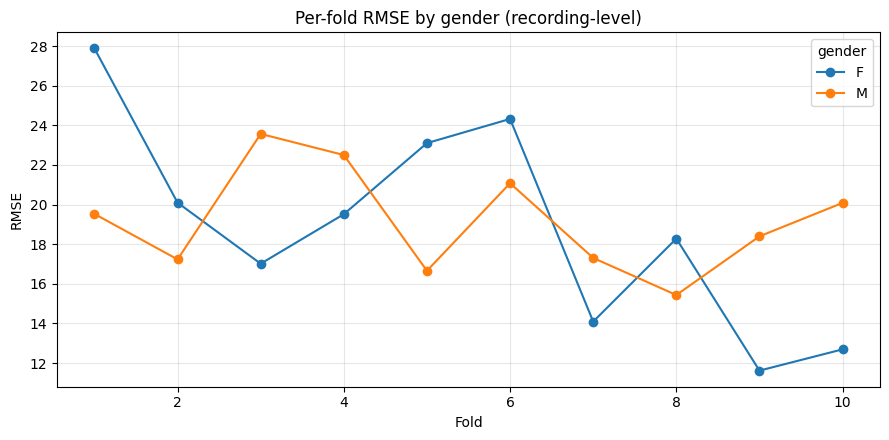

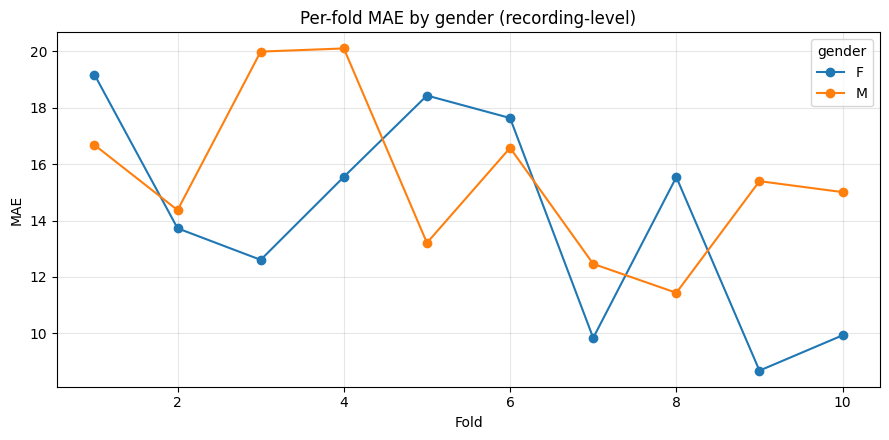

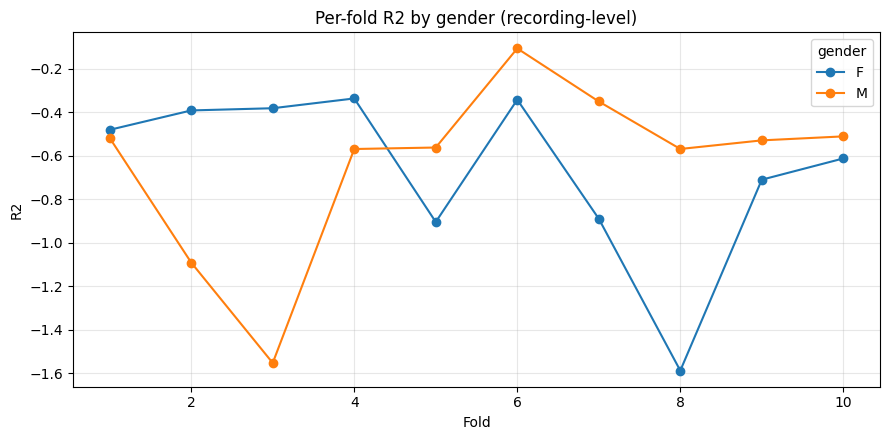

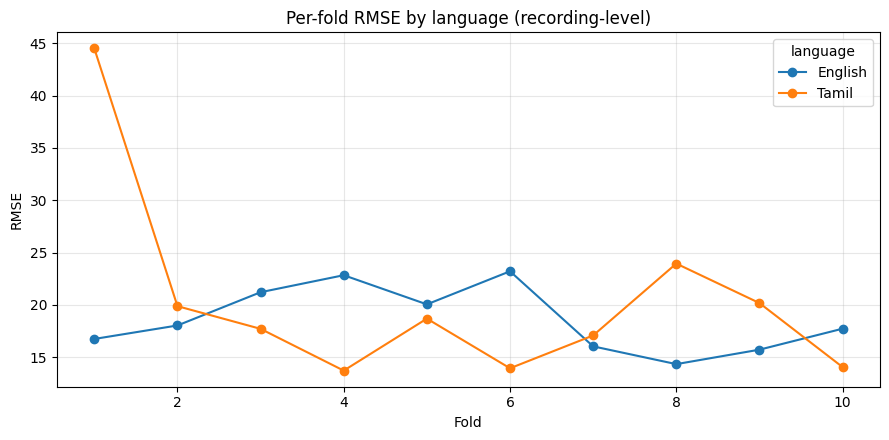

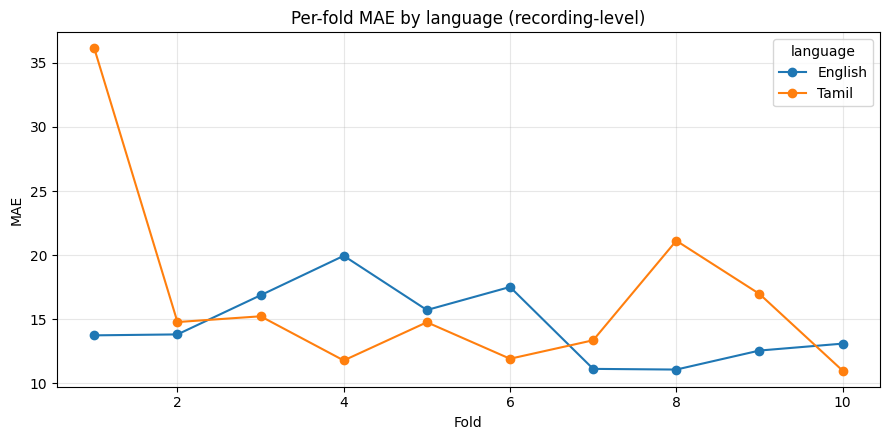

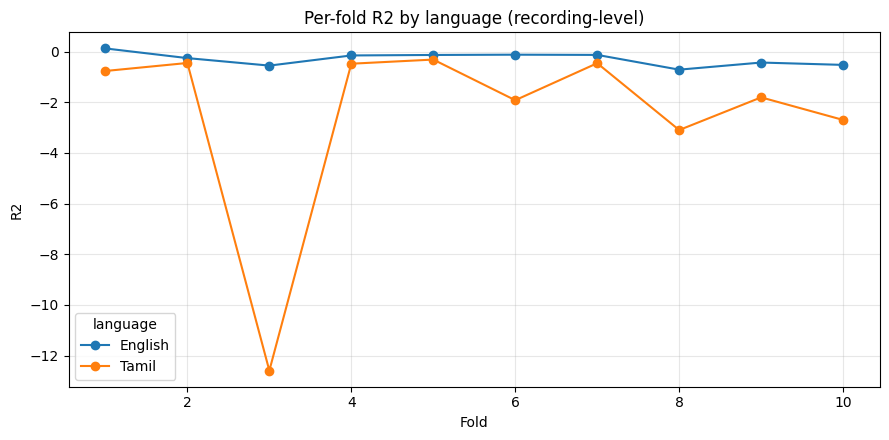


Saved per-fold plots to /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs


In [3]:
# NEW


# =============================================================================
# Final XGBoost evaluation: 10-fold speaker-independent stratified CV.
# Evaluates at BOTH frame-level and recording-level (frame predictions
# aggregated per recording). Records RMSE, MAE, and R^2 per fold for the
# full dataset and for subgroups (gender, language), then aggregates mean
# and SD across folds. Produces per-fold performance plots.
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_FOLDS      = 10
RECORDING_COL = "file_name"      # unique recording identifier in groups_train

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load training data + best hyperparameters -------------------------------
# groups_train already carries: speaker_id, file_name, language, gender, stratum
X_train      = pd.read_parquet(DATA_DIR / "X_train.parquet").reset_index(drop=True)
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns").reset_index(drop=True)
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet").reset_index(drop=True)

# Recover best hyperparameters from the previously fitted model.
best_model = XGBRegressor()
best_model.load_model(OUT_DIR / "xgb_best.json")
best_params = best_model.get_xgb_params()
best_params["random_state"] = RANDOM_STATE

# --- 10-fold speaker-independent stratified CV -------------------------------
sgkf = StratifiedGroupKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
cv_splits = list(
    sgkf.split(
        X_train,
        y=groups_train["stratum"].values,
        groups=groups_train["speaker_id"].values,
    )
)

# --- Helper: compute RMSE / MAE / R^2 on a slice -----------------------------
def compute_metrics(y_true, y_pred):
    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "n": 0}
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
        "n":    int(len(y_true)),
    }

# --- Helper: aggregate frame predictions to recording level ------------------
def aggregate_to_recording(y_true_frames, y_pred_frames, meta_va):
    """Average frame-level predictions and labels per recording."""
    df = pd.DataFrame({
        "recording_id": meta_va[RECORDING_COL].values,
        "y_true":       y_true_frames,
        "y_pred":       y_pred_frames,
        "gender":       meta_va["gender"].values,
        "language":     meta_va["language"].values,
    })
    rec = (df.groupby("recording_id")
             .agg(y_true=("y_true", "mean"),     # constant per recording
                  y_pred=("y_pred", "mean"),     # average frame predictions
                  gender=("gender", "first"),
                  language=("language", "first"))
             .reset_index())
    return rec

# --- Run the 10-fold CV ------------------------------------------------------
SUBGROUP_COLS  = ["gender", "language"]
fold_records   = []   # frame-level results
record_records = []   # recording-level results

for fold_idx, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    meta_va    = groups_train.iloc[va_idx].reset_index(drop=True)

    model = XGBRegressor(**best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_va)

    # ----- Frame-level metrics -----
    overall_frame = compute_metrics(y_va.values, y_pred)
    fold_records.append({
        "fold": fold_idx, "subgroup": "overall", "level": "all",
        **overall_frame,
    })
    for col in SUBGROUP_COLS:
        for level, mask in meta_va.groupby(col).groups.items():
            mask_idx = np.asarray(mask)
            sub = compute_metrics(y_va.values[mask_idx], y_pred[mask_idx])
            fold_records.append({
                "fold": fold_idx, "subgroup": col, "level": level, **sub,
            })

    # ----- Recording-level metrics -----
    rec = aggregate_to_recording(y_va.values, y_pred, meta_va)

    overall_rec = compute_metrics(rec["y_true"].values, rec["y_pred"].values)
    record_records.append({
        "fold": fold_idx, "subgroup": "overall", "level": "all",
        **overall_rec,
    })
    for col in SUBGROUP_COLS:
        for level, sub_df in rec.groupby(col):
            sub = compute_metrics(sub_df["y_true"].values,
                                  sub_df["y_pred"].values)
            record_records.append({
                "fold": fold_idx, "subgroup": col, "level": level, **sub,
            })

    print(f"Fold {fold_idx:2d} | "
          f"frame:  RMSE={overall_frame['RMSE']:.3f}  "
          f"MAE={overall_frame['MAE']:.3f}  R2={overall_frame['R2']:.3f}  "
          f"(n={overall_frame['n']})  | "
          f"recording: RMSE={overall_rec['RMSE']:.3f}  "
          f"MAE={overall_rec['MAE']:.3f}  R2={overall_rec['R2']:.3f}  "
          f"(n={overall_rec['n']})")

# --- Aggregate across folds: mean and SD per subgroup level ------------------
fold_df   = pd.DataFrame(fold_records)
record_df = pd.DataFrame(record_records)

def summarise(df):
    return (df.groupby(["subgroup", "level"])[["RMSE", "MAE", "R2"]]
              .agg(["mean", "std"])
              .round(3))

frame_summary  = summarise(fold_df)
record_summary = summarise(record_df)

print("\n=== Frame-level: mean (SD) across folds ===")
print(frame_summary)
print("\n=== Recording-level: mean (SD) across folds ===")
print(record_summary)

# --- Save metric tables ------------------------------------------------------
fold_df.to_csv(OUT_DIR / "xgb_cv_fold_metrics_frame.csv", index=False)
record_df.to_csv(OUT_DIR / "xgb_cv_fold_metrics_recording.csv", index=False)
frame_summary.to_csv(OUT_DIR / "xgb_cv_summary_frame.csv")
record_summary.to_csv(OUT_DIR / "xgb_cv_summary_recording.csv")
with open(OUT_DIR / "xgb_best_params.json", "w") as f:
    json.dump(best_params, f, indent=2, default=str)

# --- Plots: per-fold performance --------------------------------------------
def plot_overall_per_fold(frame_df, rec_df, metric, out_path):
    """Bar plot comparing frame-level vs recording-level for a given metric."""
    f = frame_df[(frame_df["subgroup"] == "overall")].sort_values("fold")
    r = rec_df[(rec_df["subgroup"] == "overall")].sort_values("fold")
    x = np.arange(len(f))
    w = 0.4

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x - w/2, f[metric], width=w, label="Frame-level")
    ax.bar(x + w/2, r[metric], width=w, label="Recording-level")
    ax.set_xticks(x)
    ax.set_xticklabels(f["fold"].astype(int))
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.set_title(f"Per-fold {metric} (overall)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

def plot_subgroup_per_fold(df, subgroup, metric, out_path, title_suffix):
    """Line plot of a metric across folds, one line per subgroup level."""
    sub = df[df["subgroup"] == subgroup].sort_values(["level", "fold"])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for level, g in sub.groupby("level"):
        ax.plot(g["fold"], g[metric], marker="o", label=str(level))
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.set_title(f"Per-fold {metric} by {subgroup} ({title_suffix})")
    ax.legend(title=subgroup)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show(fig)
    plt.close(fig)

# Overall (frame vs recording) for each metric
for metric in ["RMSE", "MAE", "R2"]:
    plot_overall_per_fold(
        fold_df, record_df, metric,
        OUT_DIR / f"xgb_perfold_overall_{metric}.png",
    )

# Subgroup breakdowns at recording level (the level we report)
for subgroup in SUBGROUP_COLS:
    for metric in ["RMSE", "MAE", "R2"]:
        plot_subgroup_per_fold(
            record_df, subgroup, metric,
            OUT_DIR / f"xgb_perfold_recording_{subgroup}_{metric}.png",
            title_suffix="recording-level",
        )

print(f"\nSaved per-fold plots to {OUT_DIR}")

In [ ]:
# =============================================================================
# Final XGBoost evaluation: 10-fold speaker-independent stratified CV.
# Evaluates at BOTH frame-level and recording-level (frame predictions
# aggregated per recording). Records RMSE, MAE, and R^2 per fold for the
# full dataset and for subgroups (gender, language, age_group), then
# aggregates mean and SD across folds. Produces per-fold performance plots.
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_FOLDS      = 10
DATA_DIR     = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR      = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load training data + best hyperparameters -------------------------------
X_train      = pd.read_parquet(DATA_DIR / "X_train.parquet")
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet")

# Recover best hyperparameters from the previously fitted model.
best_model = XGBRegressor()
best_model.load_model(OUT_DIR / "xgb_best.json")
best_params = best_model.get_xgb_params()
best_params["random_state"] = RANDOM_STATE

# --- Attach demographic + recording attributes to each frame -----------------
metadata = pd.read_csv(DATA_DIR / "tesdhe_metadata.csv")

speaker_attrs = (
    metadata.groupby("speaker_id")
            .agg(language=("language", "first"),
                 gender=("gender", "first"),
                 age_years=("age_years", "mean"))
            .reset_index()
)
median_age = speaker_attrs["age_years"].median()
speaker_attrs["age_group"] = (speaker_attrs["age_years"] > median_age).map(
    {True: "old", False: "young"}
)
speaker_attrs["stratum"] = (
    speaker_attrs["language"] + "_" +
    speaker_attrs["gender"]   + "_" +
    speaker_attrs["age_group"]
)

frame_meta = groups_train.merge(
    speaker_attrs[["speaker_id", "language", "gender", "age_group", "stratum"]],
    on="speaker_id", how="left",
).reset_index(drop=True)

# IMPORTANT: a column identifying each unique recording must exist in
# groups_train (or metadata). Adjust the column name below if yours differs.
RECORDING_COL = "recording_id"
if RECORDING_COL not in frame_meta.columns:
    raise KeyError(
        f"Expected '{RECORDING_COL}' column in groups_train.parquet. "
        f"Available columns: {list(frame_meta.columns)}"
    )

# --- 10-fold speaker-independent stratified CV -------------------------------
sgkf = StratifiedGroupKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
cv_splits = list(
    sgkf.split(X_train, y=frame_meta["stratum"], groups=frame_meta["speaker_id"])
)

# --- Helper: compute RMSE / MAE / R^2 on a slice -----------------------------
def compute_metrics(y_true, y_pred):
    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan, "n": 0}
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred),
        "R2":   r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan,
        "n":    len(y_true),
    }

# --- Helper: aggregate frame predictions to recording level ------------------
def aggregate_to_recording(y_true_frames, y_pred_frames, meta_va):
    """Average frame-level predictions and labels per recording."""
    df = pd.DataFrame({
        "recording_id": meta_va[RECORDING_COL].values,
        "y_true":       y_true_frames,
        "y_pred":       y_pred_frames,
        "gender":       meta_va["gender"].values,
        "language":     meta_va["language"].values,
        "age_group":    meta_va["age_group"].values,
    })
    rec = (df.groupby("recording_id")
             .agg(y_true=("y_true", "mean"),     # constant per recording
                  y_pred=("y_pred", "mean"),     # average frame predictions
                  gender=("gender", "first"),
                  language=("language", "first"),
                  age_group=("age_group", "first"))
             .reset_index())
    return rec

# --- Run the 10-fold CV ------------------------------------------------------
SUBGROUP_COLS  = ["gender", "language", "age_group"]
fold_records   = []   # frame-level results
record_records = []   # recording-level results

for fold_idx, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    meta_va    = frame_meta.iloc[va_idx].reset_index(drop=True)

    model = XGBRegressor(**best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_va)

    # ----- Frame-level metrics (as before) -----
    overall_frame = compute_metrics(y_va.values, y_pred)
    fold_records.append({
        "fold": fold_idx, "subgroup": "overall", "level": "all",
        **overall_frame,
    })
    for col in SUBGROUP_COLS:
        for level, mask in meta_va.groupby(col).groups.items():
            mask_idx = np.asarray(mask)
            sub = compute_metrics(y_va.values[mask_idx], y_pred[mask_idx])
            fold_records.append({
                "fold": fold_idx, "subgroup": col, "level": level, **sub,
            })

    # ----- Recording-level metrics (new) -----
    rec = aggregate_to_recording(y_va.values, y_pred, meta_va)

    overall_rec = compute_metrics(rec["y_true"].values, rec["y_pred"].values)
    record_records.append({
        "fold": fold_idx, "subgroup": "overall", "level": "all",
        **overall_rec,
    })
    for col in SUBGROUP_COLS:
        for level, sub_df in rec.groupby(col):
            sub = compute_metrics(sub_df["y_true"].values,
                                  sub_df["y_pred"].values)
            record_records.append({
                "fold": fold_idx, "subgroup": col, "level": level, **sub,
            })

    print(f"Fold {fold_idx:2d} | "
          f"frame:  RMSE={overall_frame['RMSE']:.3f}  MAE={overall_frame['MAE']:.3f}  R2={overall_frame['R2']:.3f}  (n={overall_frame['n']})  | "
          f"recording: RMSE={overall_rec['RMSE']:.3f}  MAE={overall_rec['MAE']:.3f}  R2={overall_rec['R2']:.3f}  (n={overall_rec['n']})")

# --- Aggregate across folds: mean and SD per subgroup level ------------------
fold_df   = pd.DataFrame(fold_records)
record_df = pd.DataFrame(record_records)

def summarise(df):
    return (df.groupby(["subgroup", "level"])[["RMSE", "MAE", "R2"]]
              .agg(["mean", "std"])
              .round(3))

frame_summary  = summarise(fold_df)
record_summary = summarise(record_df)

print("\n=== Frame-level: mean (SD) across folds ===")
print(frame_summary)
print("\n=== Recording-level: mean (SD) across folds ===")
print(record_summary)

# --- Save metric tables ------------------------------------------------------
fold_df.to_csv(OUT_DIR / "xgb_cv_fold_metrics_frame.csv", index=False)
record_df.to_csv(OUT_DIR / "xgb_cv_fold_metrics_recording.csv", index=False)
frame_summary.to_csv(OUT_DIR / "xgb_cv_summary_frame.csv")
record_summary.to_csv(OUT_DIR / "xgb_cv_summary_recording.csv")
with open(DATA_DIR / "xgb_best_params.json", "w") as f:
    json.dump(best_params, f, indent=2, default=str)

# --- Plots: per-fold performance --------------------------------------------
def plot_overall_per_fold(frame_df, rec_df, metric, out_path):
    """Bar plot comparing frame-level vs recording-level for a given metric."""
    f = frame_df[(frame_df["subgroup"] == "overall")].sort_values("fold")
    r = rec_df[(rec_df["subgroup"] == "overall")].sort_values("fold")
    x = np.arange(len(f))
    w = 0.4

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x - w/2, f[metric], width=w, label="Frame-level")
    ax.bar(x + w/2, r[metric], width=w, label="Recording-level")
    ax.set_xticks(x)
    ax.set_xticklabels(f["fold"].astype(int))
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.set_title(f"Per-fold {metric} (overall)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

def plot_subgroup_per_fold(df, subgroup, metric, out_path, title_suffix):
    """Line plot of a metric across folds, one line per subgroup level."""
    sub = df[df["subgroup"] == subgroup].sort_values(["level", "fold"])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for level, g in sub.groupby("level"):
        ax.plot(g["fold"], g[metric], marker="o", label=str(level))
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.set_title(f"Per-fold {metric} by {subgroup} ({title_suffix})")
    ax.legend(title=subgroup)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

# Overall (frame vs recording) for each metric
for metric in ["RMSE", "MAE", "R2"]:
    plot_overall_per_fold(
        fold_df, record_df, metric,
        OUT_DIR / f"xgb_perfold_overall_{metric}.png",
    )

# Subgroup breakdowns at recording level (the level we report)
for subgroup in SUBGROUP_COLS:
    for metric in ["RMSE", "MAE", "R2"]:
        plot_subgroup_per_fold(
            record_df, subgroup, metric,
            OUT_DIR / f"xgb_perfold_recording_{subgroup}_{metric}.png",
            title_suffix="recording-level",
        )

print(f"\nSaved per-fold plots to {OUT_DIR}")

Fold  1: RMSE=17.257  MAE=13.043  R2=-0.422  (n_val=97169)
Fold  2: RMSE=18.059  MAE=15.024  R2=-0.463  (n_val=86898)
Fold  3: RMSE=24.318  MAE=16.871  R2=-0.319  (n_val=103661)
Fold  4: RMSE=19.337  MAE=15.186  R2=-0.322  (n_val=98190)
Fold  5: RMSE=19.536  MAE=14.661  R2=-0.189  (n_val=95897)
Fold  6: RMSE=15.567  MAE=11.503  R2=-0.230  (n_val=97574)
Fold  7: RMSE=15.921  MAE=11.845  R2=-0.071  (n_val=96010)
Fold  8: RMSE=14.640  MAE=11.797  R2=-0.951  (n_val=95745)
Fold  9: RMSE=18.910  MAE=15.522  R2=-0.510  (n_val=95876)
Fold 10: RMSE=16.627  MAE=13.121  R2=-0.129  (n_val=101116)

=== Mean (SD) across folds ===
                     RMSE             MAE             R2       
                     mean     std    mean     std   mean    std
subgroup  level                                                
age_group old      16.253   3.528  12.784   2.850 -0.962  1.056
          young    18.901   5.233  14.845   4.013 -0.603  0.456
gender    F        18.031   5.576  14.017   3.882 -0.581

## CNN-R training and tuning

•	Decide on input shape, likely fixed-length feature vectors or framed sequences.
•	Tune number of convolution layers, filters, kernel size, dropout, dense layers, and learning rate.
•	Use early stopping and model checkpointing.
•	Save the best fold model and the final best model separately.

### Coarse Random Search for Hyperparameter Tuning

Using device: mps
Train: (890433, 92)  Val: (153965, 92)  Test: (207914, 92)
N_FEATURES: 92

Hyperparameter search: train on 890,433 frames, score on 153,965 frames
Fitting 1 folds for each of 40 candidates, totalling 40 fits
[CV] END batch_size=1024, lr=0.0001, module__dropout=0.3, module__fc1_hidden=64, module__fc2_hidden=128, module__kernel_size=3, module__n_filters=128, module__pool_size=2; total time=12.3min
[CV] END batch_size=256, lr=0.0001, module__dropout=0.5, module__fc1_hidden=256, module__fc2_hidden=128, module__kernel_size=9, module__n_filters=64, module__pool_size=2; total time=24.6min
[CV] END batch_size=512, lr=0.001, module__dropout=0.1, module__fc1_hidden=256, module__fc2_hidden=32, module__kernel_size=5, module__n_filters=128, module__pool_size=2; total time=17.4min
[CV] END batch_size=512, lr=0.001, module__dropout=0.1, module__fc1_hidden=64, module__fc2_hidden=32, module__kernel_size=3, module__n_filters=128, module__pool_size=4; total time=16.4min
[CV] END batch_s

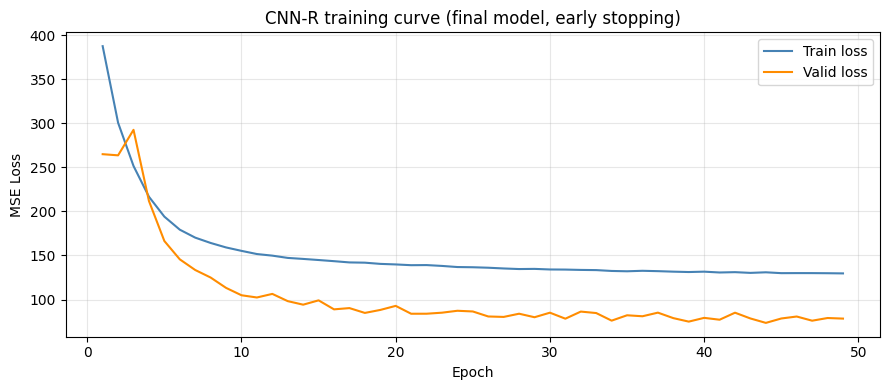

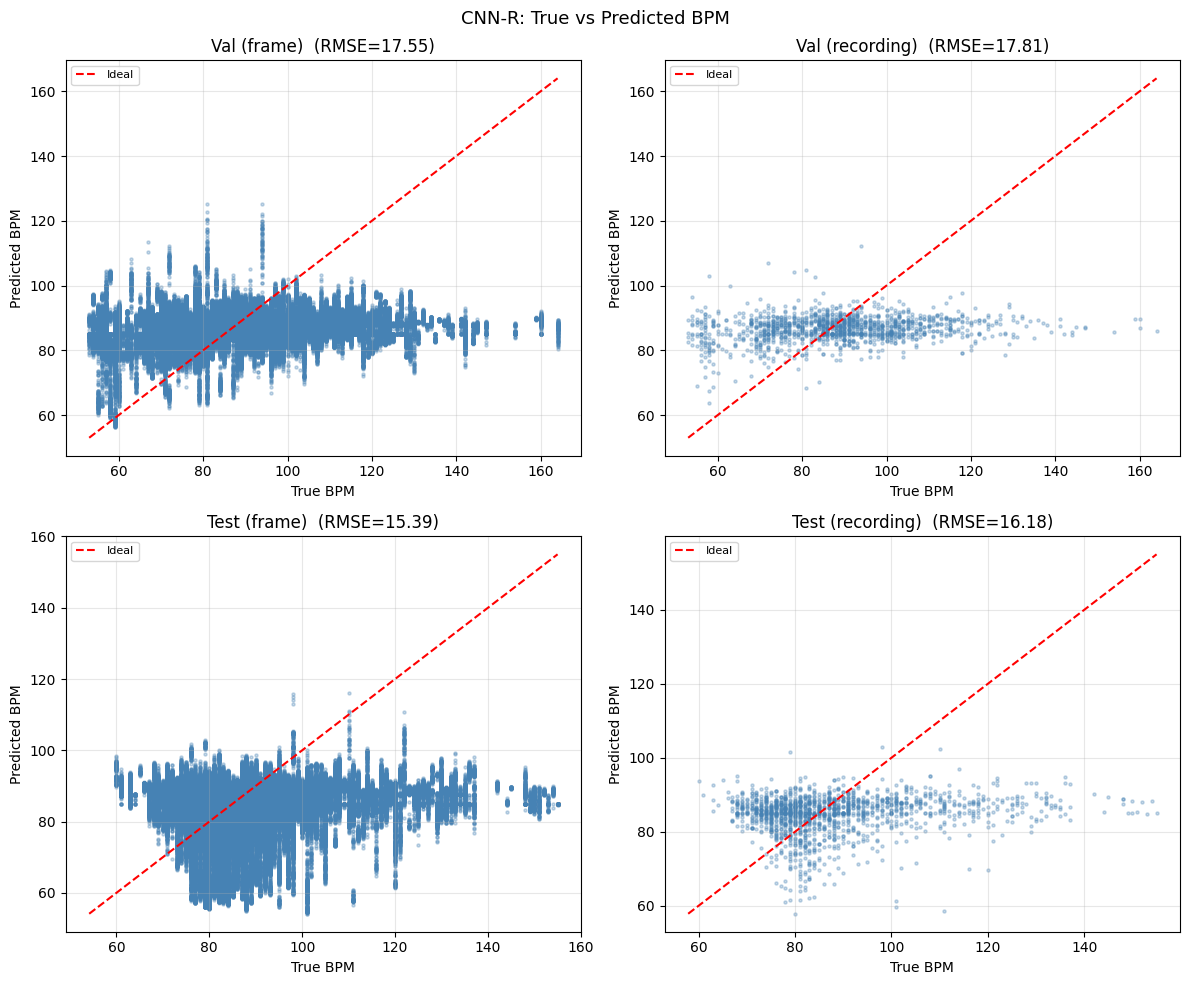

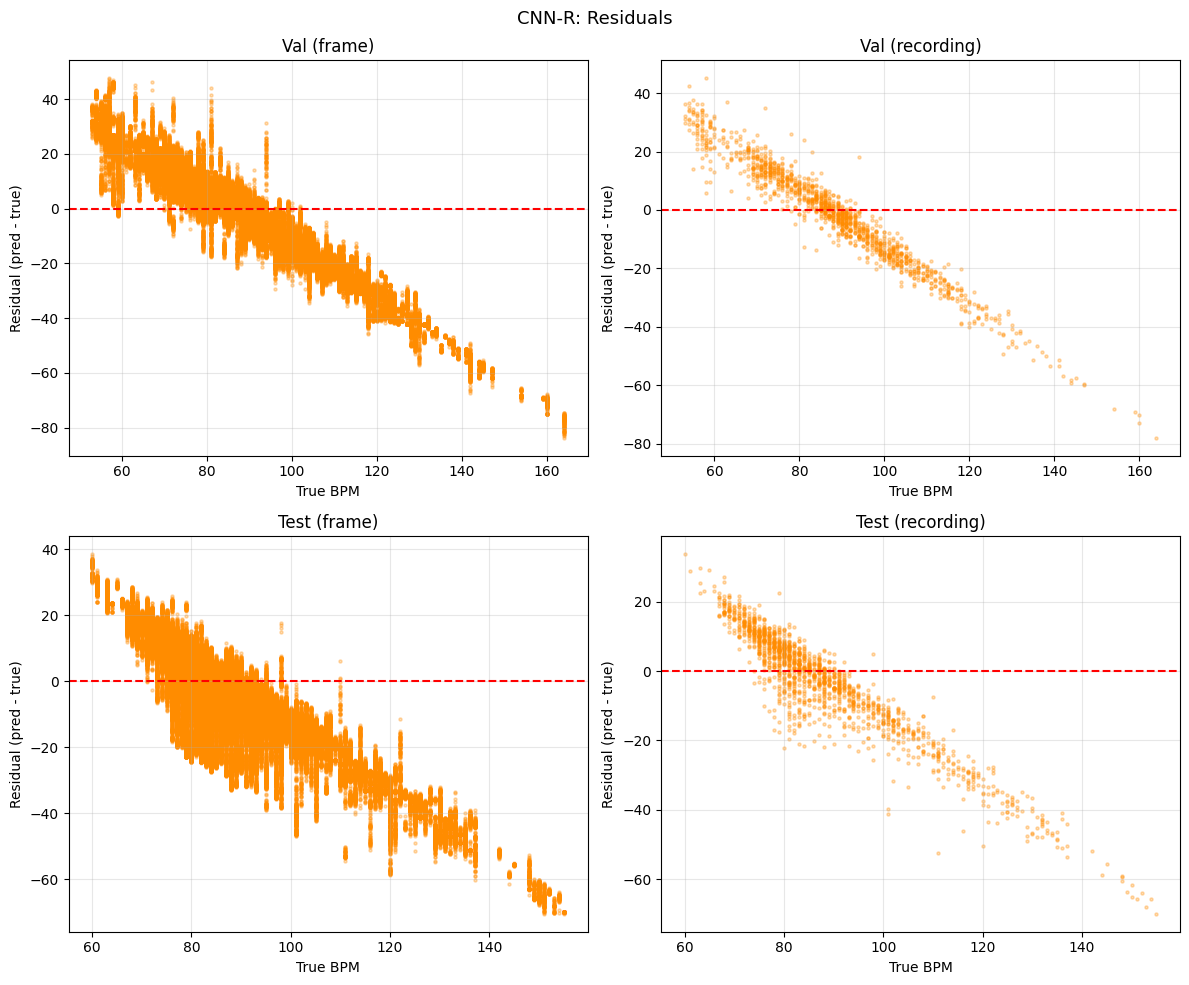

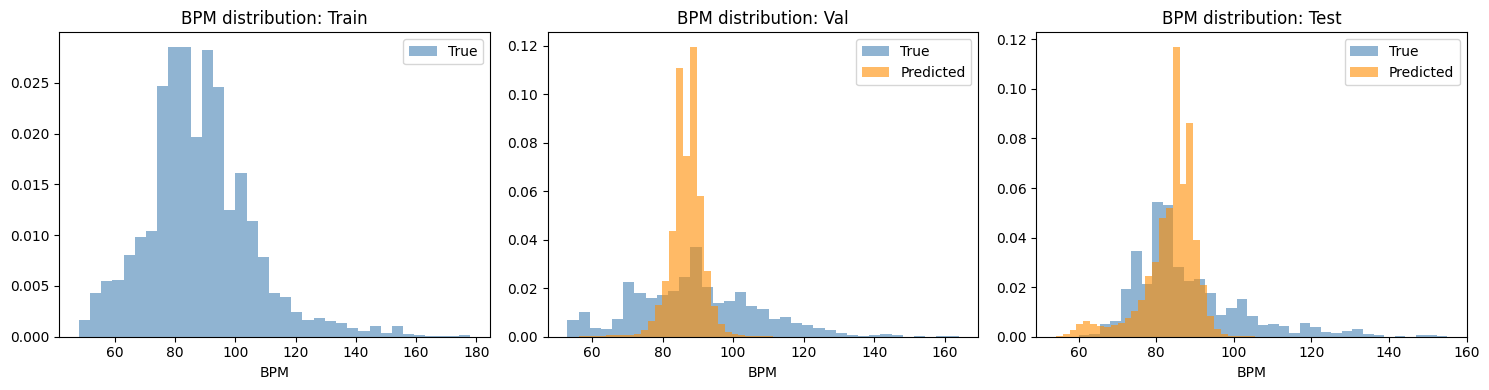

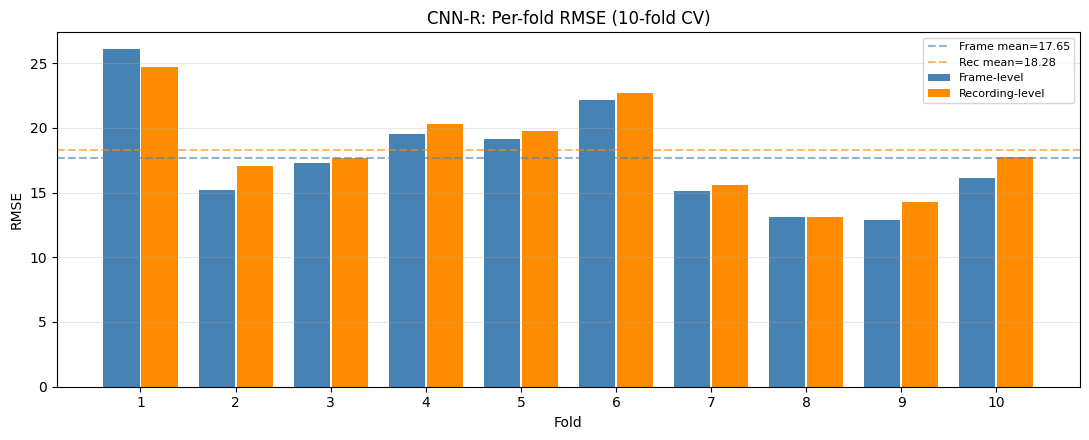

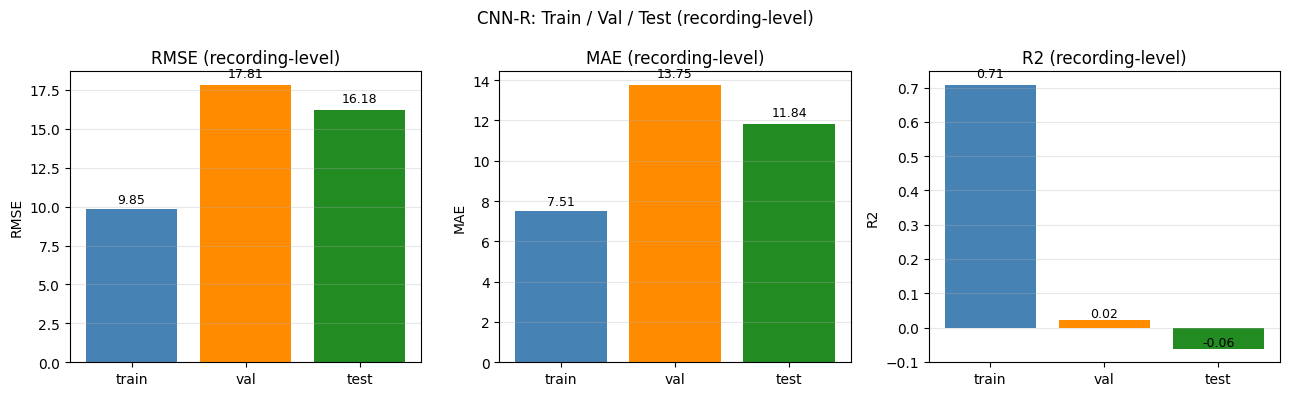

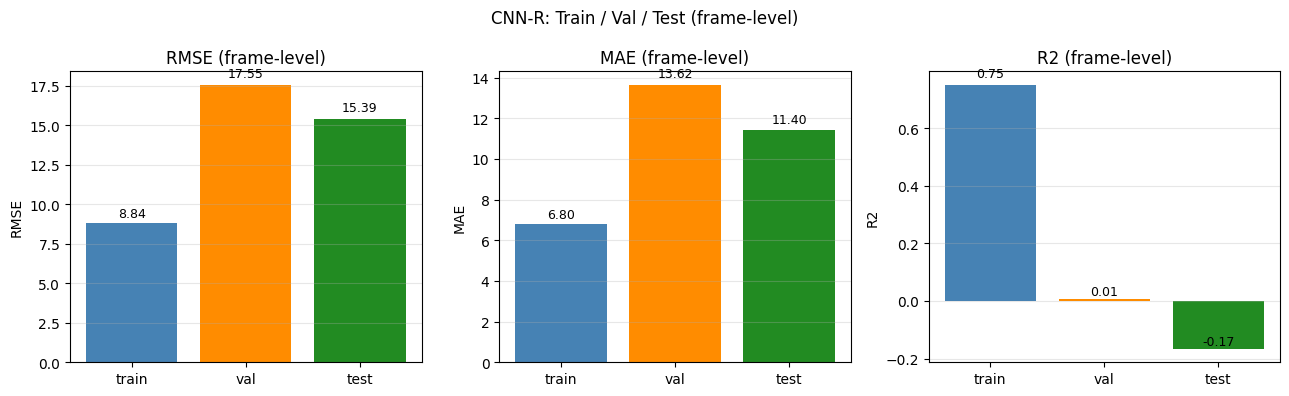

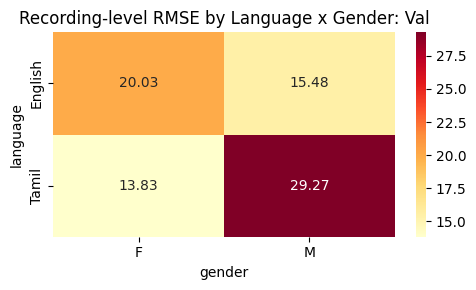

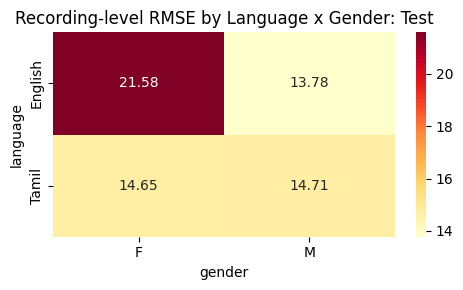

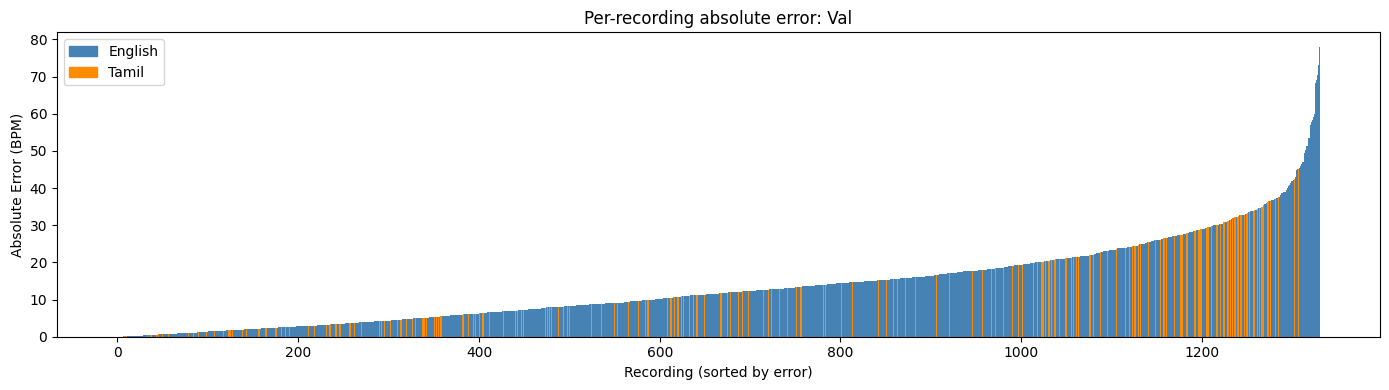

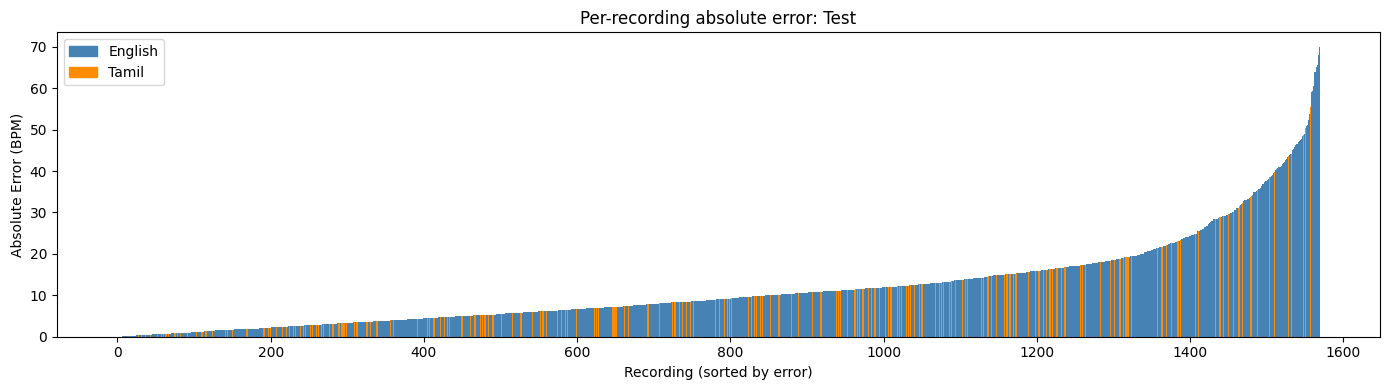


Top 10 worst recording predictions (Val):
           file_name language gender  y_true    y_pred  abs_error
En068M200437A164.ogg  English      M   164.0 85.988808  78.011192
En068M200438A160.ogg  English      M   160.0 87.006500  72.993500
En028F220937A160.ogg  English      F   160.0 89.620583  70.379417
En068M200439A159.ogg  English      M   159.0 89.808594  69.191406
En068M200440R154.ogg  English      M   154.0 85.744202  68.255798
En028F220938A147.ogg  English      F   147.0 86.958641  60.041359
En068M200441R147.ogg  English      M   147.0 87.307404  59.692596
En068M200443A144.ogg  English      M   144.0 84.754723  59.245277
En028F220939A144.ogg  English      F   144.0 85.614655  58.385345
En068M200442R145.ogg  English      M   145.0 87.298370  57.701630

Top 10 worst recording predictions (Test):
           file_name language gender  y_true    y_pred  abs_error
En063M200137A155.ogg  English      M   155.0 85.002678  69.997322
En042F220438V153.ogg  English      F   153.0 84.873505 

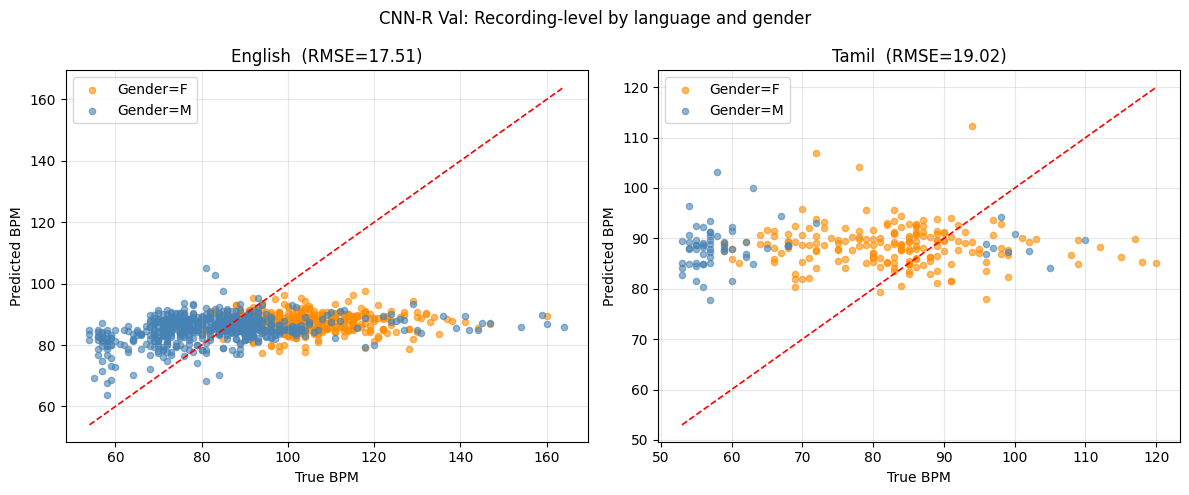

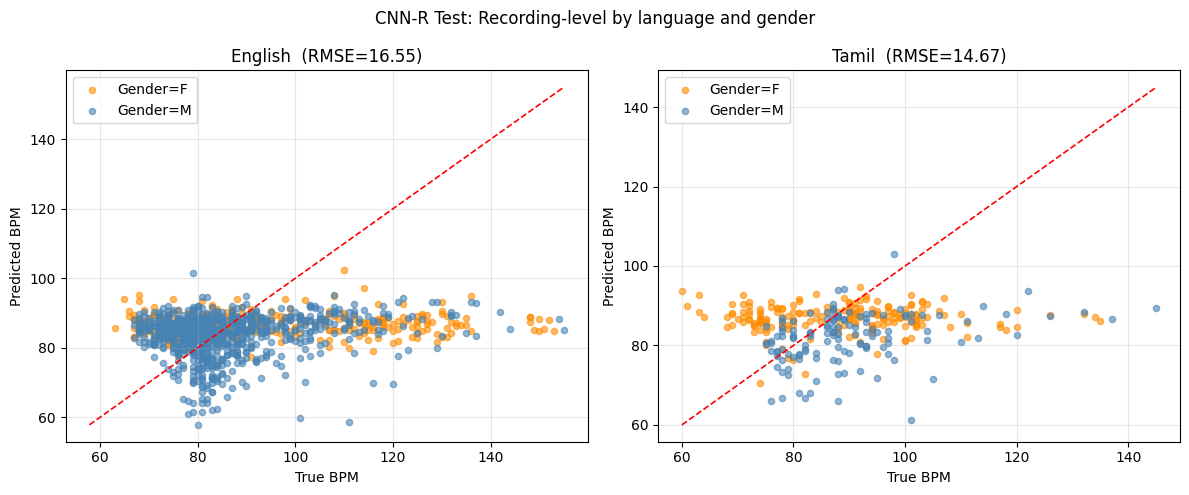


All CNN outputs saved to /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs
  cnn_all_metrics.json
  cnn_best_params.json
  cnn_best_state.pt
  cnn_bpm_distributions.png
  cnn_cv_fold_metrics_frame.csv
  cnn_cv_fold_metrics_recording.csv
  cnn_cv_summary_frame.csv
  cnn_cv_summary_recording.csv
  cnn_perfold_rmse.png
  cnn_residual_plots.png
  cnn_scatter_plots.png
  cnn_test_by_lang_gender.png
  cnn_test_heatmap_lang_gender.png
  cnn_test_per_recording_error.png
  cnn_test_recording_predictions.csv
  cnn_train_val_test_rmse_frame.png
  cnn_train_val_test_rmse_recording.png
  cnn_training_curve.png
  cnn_val_by_lang_gender.png
  cnn_val_heatmap_lang_gender.png
  cnn_val_per_recording_error.png
  cnn_val_recording_predictions.csv


In [1]:
# =============================================================================
# CNN-R hyperparameter search with recording-level scoring (refined).
#
# Architecture follows Ankishan (2019): single Conv→ReLU→Pool block,
# two FC hidden layers, regression output.
#
# Pipeline:
#   1. Coarse RandomizedSearchCV using the held-out validation set
#      (PredefinedSplit: always train on X_train, score on X_val).
#   2. Fine GridSearchCV around the coarse winner (same split).
#   3. Refit on full X_train with early stopping (ValidSplit 80/20).
#   4. Evaluate on val and test sets: frame + recording level,
#      overall and per language/gender.
#   5. 10-fold CV evaluation with the best architecture.
#   6. Visualisations and deep inspection tools.
# =============================================================================
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch")
warnings.filterwarnings("ignore", category=UserWarning, module="skorch")
warnings.filterwarnings("ignore", message=".*Attribute.*changed.*")
warnings.filterwarnings("ignore", message=".*target size.*")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.model_selection import (
    RandomizedSearchCV, GridSearchCV, StratifiedGroupKFold, PredefinedSplit
)
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from skorch import NeuralNetRegressor
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_ITER       = 40
MAX_EPOCHS   = 50
PATIENCE     = 5

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# --- Load all three splits ---------------------------------------------------
X_train      = pd.read_parquet(DATA_DIR / "X_train.parquet").reset_index(drop=True)
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns").reset_index(drop=True)
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet").reset_index(drop=True)

X_val        = pd.read_parquet(DATA_DIR / "X_val.parquet").reset_index(drop=True)
y_val        = pd.read_parquet(DATA_DIR / "y_val.parquet").squeeze("columns").reset_index(drop=True)
groups_val   = pd.read_parquet(DATA_DIR / "groups_val.parquet").reset_index(drop=True)

X_test       = pd.read_parquet(DATA_DIR / "X_test.parquet").reset_index(drop=True)
y_test       = pd.read_parquet(DATA_DIR / "y_test.parquet").squeeze("columns").reset_index(drop=True)
groups_test  = pd.read_parquet(DATA_DIR / "groups_test.parquet").reset_index(drop=True)

N_FEATURES  = X_train.shape[1]
X_train_np  = X_train.to_numpy(dtype=np.float32)
y_train_1d  = y_train.to_numpy(dtype=np.float32)
X_val_np    = X_val.to_numpy(dtype=np.float32)
y_val_1d    = y_val.to_numpy(dtype=np.float32)
X_test_np   = X_test.to_numpy(dtype=np.float32)
y_test_1d   = y_test.to_numpy(dtype=np.float32)

print(f"Train: {X_train_np.shape}  Val: {X_val_np.shape}  Test: {X_test_np.shape}")
print(f"N_FEATURES: {N_FEATURES}")

# =============================================================================
# MODEL ARCHITECTURE
# =============================================================================

class CNNRegressor(nn.Module):
    """
    Ankishan (2019) CNN-R: single Conv1d block + two FC hidden layers.
    forward() squeezes output to (batch,) to match 1-D targets and avoid
    MSELoss broadcasting warnings.
    """
    def __init__(
        self,
        n_features=N_FEATURES,
        n_filters=32,
        kernel_size=5,
        pool_size=2,
        fc1_hidden=128,
        fc2_hidden=64,
        dropout=0.3,
    ):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=n_filters,
                      kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=pool_size),
        )
        flat_size = n_filters * (n_features // pool_size)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(flat_size, fc1_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc1_hidden, fc2_hidden),
            nn.ReLU(),
            nn.Linear(fc2_hidden, 1),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)           # [batch, 1, n_features]
        x = self.conv(x)
        return self.fc(x).squeeze(-1)    # (batch,) — fixes MSELoss broadcast warning


def make_net(early_stopping=False):
    callbacks = []
    if early_stopping:
        callbacks.append(
            EarlyStopping(monitor="valid_loss", patience=PATIENCE, lower_is_better=True)
        )
    return NeuralNetRegressor(
        module=CNNRegressor,
        module__n_features=N_FEATURES,
        module__n_filters=32,
        module__kernel_size=5,
        module__pool_size=2,
        module__fc1_hidden=128,
        module__fc2_hidden=64,
        module__dropout=0.3,
        max_epochs=MAX_EPOCHS,
        criterion=nn.MSELoss,
        optimizer=torch.optim.Adam,
        lr=1e-3,
        batch_size=512,
        device=DEVICE,
        train_split=None,
        verbose=0,
        callbacks=callbacks,
        iterator_train__shuffle=True,
    )

# =============================================================================
# HYPERPARAMETER SEARCH — PredefinedSplit (train on X_train, score on X_val)
# =============================================================================

n_train = len(X_train_np)
n_val   = len(X_val_np)

X_search = np.vstack([X_train_np, X_val_np])
y_search = pd.Series(np.concatenate([y_train_1d, y_val_1d]), dtype=np.float32)

ROW_TO_FILE_SEARCH = np.concatenate([
    groups_train["file_name"].values,
    groups_val["file_name"].values,
])

test_fold = np.full(n_train + n_val, -1, dtype=np.int8)
test_fold[n_train:] = 0   # 0 = always in validation (scored); -1 = always in training
ps = PredefinedSplit(test_fold)

print(f"\nHyperparameter search: train on {n_train:,} frames, score on {n_val:,} frames")


def recording_rmse_score_search(y_true, y_pred):
    """Recording-level RMSE scorer for PredefinedSplit on combined (train+val) data."""
    if not isinstance(y_true, pd.Series):
        raise TypeError(f"y_true must be pd.Series (got {type(y_true).__name__})")
    files = ROW_TO_FILE_SEARCH[y_true.index.to_numpy()]
    df = pd.DataFrame({
        "file_name": files,
        "y_true":    y_true.values,
        "y_pred":    np.asarray(y_pred).ravel(),
    })
    rec = df.groupby("file_name").agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"))
    return -float(np.sqrt(mean_squared_error(rec["y_true"], rec["y_pred"])))


recording_rmse_scorer = make_scorer(recording_rmse_score_search, greater_is_better=True)

# --- Stage 1: Coarse random search ------------------------------------------
coarse_distributions = {
    "module__n_filters":   [16, 32, 64, 128],
    "module__kernel_size": [3, 5, 7, 9],
    "module__pool_size":   [2, 4],
    "module__fc1_hidden":  [64, 128, 256],
    "module__fc2_hidden":  [32, 64, 128],
    "module__dropout":     [0.1, 0.3, 0.5],
    "lr":                  [1e-4, 5e-4, 1e-3, 5e-3],
    "batch_size":          [256, 512, 1024],
}

random_search = RandomizedSearchCV(
    estimator=make_net(early_stopping=False),
    param_distributions=coarse_distributions,
    n_iter=N_ITER,
    scoring=recording_rmse_scorer,
    cv=ps,
    n_jobs=1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=False,
)
random_search.fit(X_search, y_search)
best_coarse = random_search.best_params_
print(f"\nBest coarse recording-level RMSE (X_val): {-random_search.best_score_:.3f}")
print(f"Best coarse params: {best_coarse}")

# --- Stage 2: Fine grid search around the coarse winner ---------------------
def neighbours(value, candidates):
    candidates = sorted(set(candidates))
    idx = candidates.index(value)
    return candidates[max(0, idx - 1) : min(len(candidates), idx + 2)]

fine_grid = {
    "module__n_filters":   neighbours(best_coarse["module__n_filters"],   coarse_distributions["module__n_filters"]),
    "module__fc1_hidden":  neighbours(best_coarse["module__fc1_hidden"],  coarse_distributions["module__fc1_hidden"]),
    "module__dropout":     neighbours(best_coarse["module__dropout"],      coarse_distributions["module__dropout"]),
    "lr":                  neighbours(best_coarse["lr"],                   coarse_distributions["lr"]),
    "module__kernel_size": [best_coarse["module__kernel_size"]],
    "module__pool_size":   [best_coarse["module__pool_size"]],
    "module__fc2_hidden":  [best_coarse["module__fc2_hidden"]],
    "batch_size":          [best_coarse["batch_size"]],
}

grid_search = GridSearchCV(
    estimator=make_net(early_stopping=False),
    param_grid=fine_grid,
    scoring=recording_rmse_scorer,
    cv=ps,
    n_jobs=1,
    verbose=2,
    refit=False,
)
grid_search.fit(X_search, y_search)
best_params = grid_search.best_params_
print(f"\nBest fine recording-level RMSE (X_val): {-grid_search.best_score_:.3f}")
print(f"Best fine params: {best_params}")

# --- Stage 3: Refit on full training set with early stopping ----------------
best_net = make_net(early_stopping=True)
best_net.set_params(train_split=ValidSplit(0.2, random_state=RANDOM_STATE))
best_net.set_params(**best_params)
best_net.fit(X_train_np, y_train_1d)

n_epochs      = len(best_net.history_)
best_val_loss = min(ep.get("valid_loss", float("inf")) for ep in best_net.history_)
print(f"\nFinal model: {n_epochs} epochs trained, best valid_loss={best_val_loss:.4f}")

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2:
        return {"n": int(len(y_true)), "RMSE": float("nan"), "MAE": float("nan"), "R2": float("nan")}
    return {
        "n":    int(len(y_true)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)),
    }


def aggregate_to_recording(df_frame):
    """Mean-aggregate frame-level predictions to recording level."""
    return (
        df_frame.groupby("file_name")
        .agg(
            y_true=("y_true", "mean"),
            y_pred=("y_pred", "mean"),
            language=("language", "first"),
            gender=("gender", "first"),
        )
        .reset_index()
    )


def make_predictions_df(net, X_np, y_1d, groups_df):
    """Return frame-level DataFrame with predictions and metadata."""
    return pd.DataFrame({
        "file_name": groups_df["file_name"].values,
        "language":  groups_df["language"].values,
        "gender":    groups_df["gender"].values,
        "y_true":    y_1d,
        "y_pred":    net.predict(X_np).ravel(),
    })


def full_metrics_block(df_frame, tag):
    """Compute frame + recording metrics: overall and per language/gender."""
    df_rec = aggregate_to_recording(df_frame)
    results = {}
    for lvl_name, df in [("frame", df_frame), ("recording", df_rec)]:
        key = f"{tag}_{lvl_name}"
        results[key] = {"overall": compute_metrics(df["y_true"], df["y_pred"])}
        for col in ["language", "gender"]:
            results[key][col] = {
                grp: compute_metrics(sub["y_true"], sub["y_pred"])
                for grp, sub in df.groupby(col)
            }
    return results, df_rec


def print_comparison_table(all_metrics):
    """Print frame + recording metrics for train/val/test with subgroup breakdown."""
    for split in ["train", "val", "test"]:
        print(f"\n--- {split.upper()} ---")
        for lvl in ["frame", "recording"]:
            key = f"{split}_{lvl}"
            if key not in all_metrics:
                continue
            m = all_metrics[key]["overall"]
            print(f"  {lvl:10s}: RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  R2={m['R2']:.3f}  n={m['n']}")
            for col in ["language", "gender"]:
                for grp, gm in sorted(all_metrics[key].get(col, {}).items()):
                    print(f"    {col}={grp:8s}: RMSE={gm['RMSE']:.3f}  MAE={gm['MAE']:.3f}  n={gm['n']}")


# --- Visualisation helpers ---------------------------------------------------

def plot_scatter(y_true, y_pred, title, ax):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ax.scatter(y_true, y_pred, alpha=0.3, s=5, color="steelblue", rasterized=True)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_xlabel("True BPM")
    ax.set_ylabel("Predicted BPM")
    ax.set_title(f"{title}  (RMSE={rmse:.2f})")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


def plot_residuals(y_true, y_pred, title, ax):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ax.scatter(y_true, y_pred - y_true, alpha=0.3, s=5, color="darkorange", rasterized=True)
    ax.axhline(0, color="red", lw=1.5, linestyle="--")
    ax.set_xlabel("True BPM")
    ax.set_ylabel("Residual (pred - true)")
    ax.set_title(title)
    ax.grid(alpha=0.3)


def plot_fold_rmse(fold_frame_df, fold_record_df, out_path):
    f = fold_frame_df[fold_frame_df["subgroup"] == "overall"].sort_values("fold")
    r = fold_record_df[fold_record_df["subgroup"] == "overall"].sort_values("fold")
    x = np.arange(len(f))
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x - 0.2, f["RMSE"], width=0.38, label="Frame-level", color="steelblue")
    ax.bar(x + 0.2, r["RMSE"], width=0.38, label="Recording-level", color="darkorange")
    ax.axhline(f["RMSE"].mean(), color="steelblue",  lw=1.5, linestyle="--", alpha=0.6,
               label=f"Frame mean={f['RMSE'].mean():.2f}")
    ax.axhline(r["RMSE"].mean(), color="darkorange", lw=1.5, linestyle="--", alpha=0.6,
               label=f"Rec mean={r['RMSE'].mean():.2f}")
    ax.set_xticks(x)
    ax.set_xticklabels(f["fold"].astype(int))
    ax.set_xlabel("Fold")
    ax.set_ylabel("RMSE")
    ax.set_title("CNN-R: Per-fold RMSE (10-fold CV)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)


def plot_bpm_distributions(y_train_true, y_val_true, y_val_pred,
                            y_test_true, y_test_pred, out_path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, true, pred, split in zip(
        axes,
        [y_train_true, y_val_true,  y_test_true],
        [None,         y_val_pred,  y_test_pred],
        ["Train",      "Val",       "Test"],
    ):
        ax.hist(true, bins=35, alpha=0.6, label="True", color="steelblue", density=True)
        if pred is not None:
            ax.hist(pred, bins=35, alpha=0.6, label="Predicted", color="darkorange", density=True)
        ax.set_title(f"BPM distribution: {split}")
        ax.set_xlabel("BPM")
        ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)


def plot_train_val_test_comparison(all_metrics, level, out_path):
    splits = ["train", "val", "test"]
    colors = ["steelblue", "darkorange", "forestgreen"]
    rmse_v = [all_metrics[f"{s}_{level}"]["overall"]["RMSE"] for s in splits]
    mae_v  = [all_metrics[f"{s}_{level}"]["overall"]["MAE"]  for s in splits]
    r2_v   = [all_metrics[f"{s}_{level}"]["overall"]["R2"]   for s in splits]
    x = np.arange(len(splits))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, vals, name in zip(axes, [rmse_v, mae_v, r2_v], ["RMSE", "MAE", "R2"]):
        ax.bar(x, vals, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(splits)
        ax.set_ylabel(name)
        ax.set_title(f"{name} ({level}-level)")
        ax.grid(axis="y", alpha=0.3)
        for i, v in enumerate(vals):
            offset = abs(v) * 0.02 if abs(v) > 0.01 else 0.005
            ax.text(i, v + offset, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    fig.suptitle(f"CNN-R: Train / Val / Test ({level}-level)", fontsize=12)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)


def inspect_worst_predictions(df_rec, n=10, tag=""):
    df = df_rec.copy()
    df["abs_error"] = (df["y_pred"] - df["y_true"]).abs()
    worst = df.nlargest(n, "abs_error")
    print(f"\nTop {n} worst recording predictions ({tag}):")
    cols = [c for c in ["file_name", "language", "gender", "y_true", "y_pred", "abs_error"]
            if c in df.columns]
    print(worst[cols].to_string(index=False))
    return worst


def inspect_per_recording(df_rec, tag, out_path):
    df = df_rec.copy()
    df["abs_error"] = (df["y_pred"] - df["y_true"]).abs()
    df_sorted = df.sort_values("abs_error").reset_index(drop=True)
    color_map = {"English": "steelblue", "Tamil": "darkorange"}
    colors = df_sorted["language"].map(color_map).fillna("grey")
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(np.arange(len(df_sorted)), df_sorted["abs_error"], color=colors, width=1.0)
    ax.set_xlabel("Recording (sorted by error)")
    ax.set_ylabel("Absolute Error (BPM)")
    ax.set_title(f"Per-recording absolute error: {tag}")
    handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
    ax.legend(handles=handles)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)


def plot_confusion_by_subgroup(df_rec, tag, out_path):
    rows = []
    for (lang, gen), sub in df_rec.groupby(["language", "gender"]):
        rows.append({
            "language": lang,
            "gender":   gen,
            "RMSE":     compute_metrics(sub["y_true"].values, sub["y_pred"].values)["RMSE"],
        })
    pivot = pd.DataFrame(rows).pivot(index="language", columns="gender", values="RMSE")
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"Recording-level RMSE by Language x Gender: {tag}")
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

# =============================================================================
# EVALUATION: TRAIN / VAL / TEST
# =============================================================================

df_train_frame = make_predictions_df(best_net, X_train_np, y_train_1d, groups_train)
df_val_frame   = make_predictions_df(best_net, X_val_np,   y_val_1d,   groups_val)
df_test_frame  = make_predictions_df(best_net, X_test_np,  y_test_1d,  groups_test)

train_results, train_rec = full_metrics_block(df_train_frame, "train")
val_results,   val_rec   = full_metrics_block(df_val_frame,   "val")
test_results,  test_rec  = full_metrics_block(df_test_frame,  "test")
all_metrics = {**train_results, **val_results, **test_results}

print("\n=== CNN-R performance summary ===")
print_comparison_table(all_metrics)

# =============================================================================
# 10-FOLD CV EVALUATION WITH BEST ARCHITECTURE
# =============================================================================

N_CV_FOLDS = 10
sgkf_cv = StratifiedGroupKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits_eval = list(sgkf_cv.split(
    X_train_np,
    y=groups_train["stratum"].values,
    groups=groups_train["speaker_id"].values,
))

fold_frame_rows  = []
fold_record_rows = []

print(f"\n=== 10-fold CV evaluation (best architecture) ===")
print(f"{'Fold':>4} | {'Frame RMSE':>10} {'Frame MAE':>9} | {'Rec RMSE':>9} {'Rec MAE':>8} {'n_rec':>6}")
print("-" * 58)

for fold_idx, (tr_idx, va_idx) in enumerate(cv_splits_eval, start=1):
    X_tr, X_va = X_train_np[tr_idx], X_train_np[va_idx]
    y_tr, y_va = y_train_1d[tr_idx], y_train_1d[va_idx]
    meta_va = groups_train.iloc[va_idx].reset_index(drop=True)

    fold_net = make_net(early_stopping=False)
    fold_net.set_params(**best_params)
    fold_net.fit(X_tr, y_tr)
    y_pred_fold = fold_net.predict(X_va).ravel()

    # Frame-level
    mf = compute_metrics(y_va, y_pred_fold)
    fold_frame_rows.append({"fold": fold_idx, "subgroup": "overall", "level": "all", **mf})
    for col in ["language", "gender"]:
        for grp, sub_idx in meta_va.groupby(col).groups.items():
            sidx = np.asarray(sub_idx)
            fold_frame_rows.append({
                "fold": fold_idx, "subgroup": col, "level": str(grp),
                **compute_metrics(y_va[sidx], y_pred_fold[sidx]),
            })

    # Recording-level
    fold_frame_tmp = pd.DataFrame({
        "file_name": meta_va["file_name"].values,
        "language":  meta_va["language"].values,
        "gender":    meta_va["gender"].values,
        "y_true":    y_va,
        "y_pred":    y_pred_fold,
    })
    rec = aggregate_to_recording(fold_frame_tmp)
    mr = compute_metrics(rec["y_true"].values, rec["y_pred"].values)
    fold_record_rows.append({"fold": fold_idx, "subgroup": "overall", "level": "all", **mr})
    for col in ["language", "gender"]:
        for grp, sub_df in rec.groupby(col):
            fold_record_rows.append({
                "fold": fold_idx, "subgroup": col, "level": str(grp),
                **compute_metrics(sub_df["y_true"].values, sub_df["y_pred"].values),
            })

    print(f"{fold_idx:>4} | {mf['RMSE']:>10.3f} {mf['MAE']:>9.3f} | "
          f"{mr['RMSE']:>9.3f} {mr['MAE']:>8.3f} {mr['n']:>6}")

fold_frame_df  = pd.DataFrame(fold_frame_rows)
fold_record_df = pd.DataFrame(fold_record_rows)


def summarise_cv(df):
    return (
        df.groupby(["subgroup", "level"])[["RMSE", "MAE", "R2"]]
        .agg(["mean", "std"])
        .round(3)
    )


print("\n=== Frame-level CV summary (mean +/- std, 10 folds) ===")
print(summarise_cv(fold_frame_df))
print("\n=== Recording-level CV summary (mean +/- std, 10 folds) ===")
print(summarise_cv(fold_record_df))

# =============================================================================
# VISUALISATIONS
# =============================================================================

# 1. Training loss curve
fig, ax = plt.subplots(figsize=(9, 4))
epochs     = [ep["epoch"]                        for ep in best_net.history_]
train_loss = [ep["train_loss"]                   for ep in best_net.history_]
valid_loss = [ep.get("valid_loss", float("nan")) for ep in best_net.history_]
ax.plot(epochs, train_loss, label="Train loss", color="steelblue")
ax.plot(epochs, valid_loss, label="Valid loss", color="darkorange")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("CNN-R training curve (final model, early stopping)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "cnn_training_curve.png", dpi=200)
plt.show()
plt.close(fig)

# 2. Scatter plots — 4 panels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_scatter(df_val_frame["y_true"],  df_val_frame["y_pred"],  "Val (frame)",      axes[0, 0])
plot_scatter(val_rec["y_true"],        val_rec["y_pred"],        "Val (recording)",  axes[0, 1])
plot_scatter(df_test_frame["y_true"], df_test_frame["y_pred"], "Test (frame)",     axes[1, 0])
plot_scatter(test_rec["y_true"],       test_rec["y_pred"],       "Test (recording)", axes[1, 1])
fig.suptitle("CNN-R: True vs Predicted BPM", fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / "cnn_scatter_plots.png", dpi=200)
plt.show()
plt.close(fig)

# 3. Residual plots — 4 panels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_residuals(df_val_frame["y_true"],  df_val_frame["y_pred"],  "Val (frame)",      axes[0, 0])
plot_residuals(val_rec["y_true"],        val_rec["y_pred"],        "Val (recording)",  axes[0, 1])
plot_residuals(df_test_frame["y_true"], df_test_frame["y_pred"], "Test (frame)",     axes[1, 0])
plot_residuals(test_rec["y_true"],       test_rec["y_pred"],       "Test (recording)", axes[1, 1])
fig.suptitle("CNN-R: Residuals", fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / "cnn_residual_plots.png", dpi=200)
plt.show()
plt.close(fig)

# 4. BPM distribution overlays
plot_bpm_distributions(
    y_train_1d, y_val_1d, df_val_frame["y_pred"].values,
    y_test_1d,  df_test_frame["y_pred"].values,
    OUT_DIR / "cnn_bpm_distributions.png",
)

# 5. Per-fold RMSE (10-fold CV)
plot_fold_rmse(fold_frame_df, fold_record_df, OUT_DIR / "cnn_perfold_rmse.png")

# 6. Train / Val / Test comparison
plot_train_val_test_comparison(all_metrics, "recording",
                                OUT_DIR / "cnn_train_val_test_rmse_recording.png")
plot_train_val_test_comparison(all_metrics, "frame",
                                OUT_DIR / "cnn_train_val_test_rmse_frame.png")

# 7. Language x gender RMSE heatmaps
plot_confusion_by_subgroup(val_rec,  "Val",  OUT_DIR / "cnn_val_heatmap_lang_gender.png")
plot_confusion_by_subgroup(test_rec, "Test", OUT_DIR / "cnn_test_heatmap_lang_gender.png")

# 8. Per-recording sorted error bars
inspect_per_recording(val_rec,  "Val",  OUT_DIR / "cnn_val_per_recording_error.png")
inspect_per_recording(test_rec, "Test", OUT_DIR / "cnn_test_per_recording_error.png")

# =============================================================================
# DEEP INSPECTION
# =============================================================================

inspect_worst_predictions(val_rec,  n=10, tag="Val")
inspect_worst_predictions(test_rec, n=10, tag="Test")

# Recording-level scatter by language and gender
for split_name, df_rec in [("val", val_rec), ("test", test_rec)]:
    langs = sorted(df_rec["language"].unique())
    fig, axes = plt.subplots(1, len(langs), figsize=(6 * len(langs), 5))
    if len(langs) == 1:
        axes = [axes]
    gender_colors = {"M": "steelblue", "F": "darkorange"}
    for ax, lang in zip(axes, langs):
        sub = df_rec[df_rec["language"] == lang]
        for gen, g in sub.groupby("gender"):
            ax.scatter(g["y_true"], g["y_pred"], alpha=0.6, s=20,
                       color=gender_colors.get(gen, "grey"), label=f"Gender={gen}")
        lo = min(sub["y_true"].min(), sub["y_pred"].min())
        hi = max(sub["y_true"].max(), sub["y_pred"].max())
        ax.plot([lo, hi], [lo, hi], "r--", lw=1.2)
        rmse = np.sqrt(mean_squared_error(sub["y_true"], sub["y_pred"]))
        ax.set_title(f"{lang}  (RMSE={rmse:.2f})")
        ax.set_xlabel("True BPM")
        ax.set_ylabel("Predicted BPM")
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(f"CNN-R {split_name.capitalize()}: Recording-level by language and gender")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"cnn_{split_name}_by_lang_gender.png", dpi=200)
    plt.show()
    plt.close(fig)

# =============================================================================
# SAVE EVERYTHING
# =============================================================================

torch.save(best_net.module_.state_dict(), OUT_DIR / "cnn_best_state.pt")

with open(OUT_DIR / "cnn_best_params.json", "w") as f:
    json.dump(best_params, f, indent=2, default=str)


def _jsonify(obj):
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    raise TypeError(f"Not JSON serializable: {type(obj)}")


with open(OUT_DIR / "cnn_all_metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2, default=_jsonify)

val_rec.to_csv(OUT_DIR  / "cnn_val_recording_predictions.csv",  index=False)
test_rec.to_csv(OUT_DIR / "cnn_test_recording_predictions.csv", index=False)
fold_frame_df.to_csv(OUT_DIR  / "cnn_cv_fold_metrics_frame.csv",     index=False)
fold_record_df.to_csv(OUT_DIR / "cnn_cv_fold_metrics_recording.csv", index=False)
summarise_cv(fold_frame_df).to_csv(OUT_DIR  / "cnn_cv_summary_frame.csv")
summarise_cv(fold_record_df).to_csv(OUT_DIR / "cnn_cv_summary_recording.csv")

print(f"\nAll CNN outputs saved to {OUT_DIR}")
for p in sorted(OUT_DIR.glob("cnn_*")):
    print(f"  {p.name}")


### Results

The results of ML models training are unsatisfactory and are poorer than the Mean Predictor results. Therefore, an algorithm trained only on the samples of one person will be created, to test the correctness of my pipeline/feasibility of this bpm extraction.

## Model comparison

After training, compare the models on exactly the same folds and the same evaluation protocol. Because your thesis aims to improve on prior work, the comparison should be statistically transparent rather than just descriptive.

Compare:

	•	Mean RMSE across folds.
	•	Mean MAE across folds.
	•	Mean  across folds.
	•	Fold-by-fold prediction errors.
	•	Error distributions by subgroup.

Also report:

	•	Whether the improvement over the baseline is consistent across folds.
	•	Which model is more stable.
	•	Whether one model performs better for certain groups.
    
A simple table with fold means and standard deviations is usually enough for the thesis chapter, but keep the raw fold outputs in CSV.

## Interpretability with SHAP

Once you have the best-performing model, add interpretability. Your proposal mentions SHAP and Pearson correlations, so this part should connect the predictive model to human-readable acoustic cues.

Recommended steps:

	•	Compute SHAP values for the best model.
	•	Rank features by average absolute SHAP value.
	•	Compare SHAP rankings to feature correlations with interpretable features like F0, jitter, shimmer, entropy, skewness, and kurtosis.
	•	Check whether the top features are stable across folds.
	•	Visualize a few individual predictions with local explanations.

Useful outputs:

	•	Global SHAP summary plot.
	•	Bar plot of top 10 features.
	•	Dependence plots for the strongest predictors.
	•	A table linking top MFCCs to interpretable acoustic patterns.

## Fairness analysis and bias mitigation

Fairness should not be a separate afterthought; it should be integrated into model evaluation once the main models are trained. Since your proposal plans subgroup analysis for male/female, Tamil/English, and young/old, you should treat each subgroup as a reporting axis.

Evaluate:

	•	RMSE by subgroup.
	•	MAE by subgroup.
	•	 by subgroup.
	•	Error gap between groups.
	•	Per-fold subgroup differences.

Then test whether differences are statistically meaningful:

	•	Paired t-tests on fold-wise errors.
	•	Confidence intervals for subgroup error gaps.
	•	If possible, bootstrap the error difference for robustness.

If unfairness appears:

	•	Reweight samples.
	•	Try Fairlearn-style regression constraints or bounded group loss.
	•	Compare before/after subgroup errors.

## Final reporting and figures

The final coding pipeline should end with a clean set of thesis-ready deliverables. This makes the analysis easier to write up and also protects you from last-minute confusion.

Produce:

	•	A final results CSV with all fold metrics.
	•	A subgroup metrics CSV.
	•	A feature-importance CSV.
	•	Figures for performance, SHAP, and fairness gaps.
	•	A reproducible notebook or script pipeline.
	•	A short experiment log listing every configuration you ran.